# SkyGuard AI — Final 2025 blind evaluation

## Frozen Iteration 3 versus Iteration 5 comparison

This notebook first reconstructs the complete accepted development pipeline. It then verifies the exact Iteration 5 model files, policy, and development confusion matrices before it can open a separately sealed NOAA/NCEI 2025 benchmark.

The blind section has **no threshold search, model fitting, calibration, feature selection, or policy selection**. It evaluates the frozen Iteration 3 reference and Iteration 5 weak-fault consensus once on:

- a later-time test using the 20 development-station identities;
- a later-time test using four stations never used for model training;
- injected sensor/data faults, genuine regional weather events, and operational communication replay.

Keep `UNLOCK_BLIND_2025 = False` until all earlier cells complete and the development-lock cell passes. Then change that single flag to `True` and run the blind section once.


## Run instructions

Use the same Google Drive bundle and Iteration 1 model directory. Select a T4 GPU, run all cells, and leave `UNLOCK_FINAL_TESTS=False`. This notebook does not retrain the rejected TCN.


In [1]:
!pip -q install catboost==1.2.10 lightgbm==4.6.0 scikit-learn==1.7.2 pyarrow==21.0.0 psutil==7.0.0
from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 24.0 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
from pathlib import Path
DRIVE_ROOT=Path('/content/drive/MyDrive/SkyGuard_AI_GPU')
BUNDLE_ZIP=DRIVE_ROOT/'SkyGuard_GPU_Data_Bundle.zip'
DATA_ROOT=DRIVE_ROOT/'SkyGuard_GPU_Data_Bundle'
ITER1=DRIVE_ROOT/'experiments'/'iteration_01_detection'
ARTIFACT_ROOT=DRIVE_ROOT/'experiments'/'iteration_02_weak_fault_rescue'
ARTIFACT_ROOT.mkdir(parents=True,exist_ok=True)

UNLOCK_FINAL_TESTS=False
REUSE_SAVED_MODELS=True
SEEDS=[17,29,41,53,67]
SPECIALIST_SEEDS=[17,41,67]
print('Iteration 1:',ITER1)
print('Iteration 2:',ARTIFACT_ROOT)


Iteration 1: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/iteration_01_detection
Iteration 2: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/iteration_02_weak_fault_rescue


In [4]:
import os,json,time,math,hashlib,zipfile,warnings,platform
import joblib,numpy as np,pandas as pd,matplotlib.pyplot as plt,psutil
from IPython.display import display
from sklearn.metrics import average_precision_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
import torch

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',50)
pd.set_option('display.float_format',lambda x:f'{x:,.5f}')
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print({'python':platform.python_version(),'device':DEVICE,
       'gpu':torch.cuda.get_device_name(0) if DEVICE=='cuda' else None,
       'ram_gb':round(psutil.virtual_memory().total/2**30,2)})
assert DEVICE=='cuda','Select a GPU runtime.'

if not DATA_ROOT.exists():
    assert BUNDLE_ZIP.exists(),f'Missing {BUNDLE_ZIP}'
    with zipfile.ZipFile(BUNDLE_ZIP) as archive: archive.extractall(DRIVE_ROOT)


{'python': '3.13.15', 'device': 'cuda', 'gpu': 'Tesla T4', 'ram_gb': 12.67}


## 1. Load exact development partitions and Phase 10 contract

In [5]:
FEATURE_DIR=DATA_ROOT/'data'/'features_phase10'
BASELINE_FILE=DATA_ROOT/'models'/'phase10_final.joblib'

def load_table(name):
    frame=pd.read_csv(FEATURE_DIR/f'{name}_features.csv.gz',low_memory=False)
    frame['station_id']=frame.station_id.astype(str)
    frame['emitted_timestamp_utc']=pd.to_datetime(frame.emitted_timestamp_utc,utc=True)
    frame['episode_id']=frame.episode_id.fillna('').astype(str)
    return frame.sort_values(['station_id','emitted_timestamp_utc','row_id']).reset_index(drop=True)

train=load_table('train'); validation=load_table('validation')
train['dev_split']='train'
ts=validation.emitted_timestamp_utc
validation['dev_split']=np.select(
    [ts<'2023-05-01',ts<'2023-07-01',ts<'2023-10-01'],
    ['tune_model','block_may_jun','block_jul_sep'],default='block_oct_dec')
episode_part=(validation.loc[validation.episode_id.ne('')].sort_values('emitted_timestamp_utc')
              .groupby('episode_id').dev_split.first())
mask=validation.episode_id.ne('')
validation.loc[mask,'dev_split']=validation.loc[mask,'episode_id'].map(episode_part)
dev=pd.concat([train,validation],ignore_index=True)
del train,validation
dev=dev.loc[dev.available_to_detector.eq(1)].copy().reset_index(drop=True)

bundle=joblib.load(BASELINE_FILE); FEATURES=list(bundle['event_features'])
assert len(FEATURES)==108 and not ({'temperature_dewpoint_spread_c','hour_sin','hour_cos','day_of_year_sin','day_of_year_cos'}&set(FEATURES))
assert dev.loc[dev.episode_id.ne('')].groupby('episode_id').dev_split.nunique().max()==1
display(dev.groupby('dev_split').agg(rows=('row_id','size'),fault_rows=('is_anomaly','sum'),
                                     episodes=('episode_id',lambda s:s[s.ne('')].nunique()),stations=('station_id','nunique')))


,rows,fault_rows,episodes,stations
dev_split,,,,
block_jul_sep,46803,375,28,20
block_may_jun,29012,243,23,20
block_oct_dec,47599,471,37,20
train,182122,2270,185,20
tune_model,57894,445,36,20


## 2. Exact Phase 10 and Iteration 1 CatBoost scores

In [7]:
event_model=bundle['event_model']; classes=list(event_model.classes_)
fault_index=classes.index('sensor_fault'); weather_index=classes.index('genuine_weather')
proba=event_model.predict_proba(dev[FEATURES].replace([np.inf,-np.inf],np.nan))
dev['phase10_fault']=proba[:,fault_index]; dev['phase10_weather']=proba[:,weather_index]
PHASE10_THRESHOLD=float(bundle['policy']['known_station']['threshold'])

def load_cat_models(prefix,seeds):
    models=[]
    for seed in seeds:
        path=ITER1/f'{prefix}_seed{seed}.cbm'
        assert path.exists(),f'Missing {path}. Run Iteration 1 CatBoost cell or restore Drive artifacts.'
        model=CatBoostClassifier(); model.load_model(path); models.append(model)
    return models

fault_models=load_cat_models('cat_fault',SEEDS)
weather_models=load_cat_models('cat_weather',SEEDS)
X=dev[FEATURES]
fault_seed_scores=np.column_stack([m.predict_proba(X)[:,1] for m in fault_models])
weather_seed_scores=np.column_stack([m.predict_proba(X)[:,1] for m in weather_models])
dev['cat_fault_mean']=fault_seed_scores.mean(1)
dev['cat_fault_median']=np.median(fault_seed_scores,axis=1)
dev['cat_weather_mean']=weather_seed_scores.mean(1)
dev['cat_weather_median']=np.median(weather_seed_scores,axis=1)
print('Loaded',len(fault_models),'fault and',len(weather_models),'weather models.')


Loaded 5 fault and 5 weather models.


## 3. Strict metrics and fast causal alert policies

In [8]:
def point_metrics(y,p,score):
    y=np.asarray(y,int); p=np.asarray(p,bool); score=np.asarray(score,float)
    tn,fp,fn,tp=confusion_matrix(y,p,labels=[0,1]).ravel()
    return {'tp':int(tp),'fp':int(fp),'fn':int(fn),'tn':int(tn),
            'precision':precision_score(y,p,zero_division=0),'recall':recall_score(y,p,zero_division=0),
            'f1':f1_score(y,p,zero_division=0),'auprc':average_precision_score(y,score)}

def predicted_events(group,pred_col):
    g=group.sort_values('emitted_timestamp_utc'); times=g.emitted_timestamp_utc.tolist(); pred=g[pred_col].to_numpy(bool)
    dt=g.emitted_timestamp_utc.diff().dt.total_seconds().div(60); positive=dt[dt.gt(0)]
    gap=max(60,2.5*(float(positive.median()) if len(positive) else 60))
    events=[]; start=None; previous=None
    for pos in np.flatnonzero(pred):
        separated=(previous is None or pos!=previous+1 or (times[pos]-times[previous]).total_seconds()/60>gap)
        if separated:
            if start is not None: events.append((times[start],times[previous]))
            start=pos
        previous=pos
    if start is not None: events.append((times[start],times[previous]))
    return events

def event_metrics(frame,pred_col):
    truth=[]
    labelled=frame.loc[frame.is_anomaly.eq(1)&frame.episode_id.ne('')]
    for (station,episode),g in labelled.groupby(['station_id','episode_id']):
        truth.append((station,episode,g.emitted_timestamp_utc.min(),g.emitted_timestamp_utc.max(),g.anomaly_type.mode().iloc[0]))
    predictions=[]; station_days=0
    for station,g in frame.groupby('station_id',sort=False):
        g=g.sort_values('emitted_timestamp_utc'); station_days+=max((g.emitted_timestamp_utc.iloc[-1]-g.emitted_timestamp_utc.iloc[0]).total_seconds()/86400,1/24)
        predictions.extend((station,a,b) for a,b in predicted_events(g,pred_col))
    used=set(); hits=[]; delays=[]; per_fault={}
    for station,episode,start,end,fault in truth:
        candidates=[(i,p) for i,p in enumerate(predictions) if i not in used and p[0]==station and p[1]<=end and p[2]>=start]
        hit=bool(candidates)
        if hit:
            i,p=min(candidates,key=lambda item:item[1][1]); used.add(i); delays.append(max(0,(max(start,p[1])-start).total_seconds()/60))
        hits.append(hit); per_fault.setdefault(fault,[]).append(hit)
    tp=sum(hits); fp=len(predictions)-len(used); fn=len(truth)-tp
    ep=tp/max(tp+fp,1); er=tp/max(tp+fn,1)
    return {'true_episodes':len(truth),'predicted_episodes':len(predictions),'event_precision':ep,'event_recall':er,
            'event_f1':2*ep*er/max(ep+er,1e-12),'false_alarm_episodes_per_station_day':fp/max(station_days,1e-12),
            'delay_median_min':float(np.median(delays)) if delays else None,'delay_p90_min':float(np.quantile(delays,.9)) if delays else None,
            'delay_mean_min':float(np.mean(delays)) if delays else None,
            'per_fault_episode_recall':{k:float(np.mean(v)) for k,v in sorted(per_fault.items())}}

def hysteresis(frame,score_col,start,cont):
    result=pd.Series(False,index=frame.index)
    for _,g in frame.groupby('station_id',sort=False):
        g=g.sort_values('emitted_timestamp_utc'); active=False; out=np.zeros(len(g),bool)
        for pos,score in enumerate(g[score_col].fillna(0).to_numpy(float)):
            if not active and score>=start: active=True
            elif active and score<cont: active=False
            out[pos]=active
        result.loc[g.index]=out
    return result

def persistent_signal(frame,score_col,threshold,min_points):
    result=pd.Series(False,index=frame.index)
    for _,g in frame.groupby('station_id',sort=False):
        g=g.sort_values('emitted_timestamp_utc'); run=0; out=np.zeros(len(g),bool)
        for pos,score in enumerate(g[score_col].fillna(0).to_numpy(float)):
            run=run+1 if score>=threshold else 0
            out[pos]=run>=min_points
        result.loc[g.index]=out
    return result

def evaluate(frame,score_col,pred_col): return {**point_metrics(frame.is_anomaly,frame[pred_col],frame[score_col]),**event_metrics(frame,pred_col)}


## 4. Train focused frozen, bias, and drift specialists

Each specialist uses a small causal feature family and three fixed seeds. Models train on 2022, use January–April 2023 only for early stopping, and never see the three robust policy blocks during fitting.


In [9]:
FROZEN_FEATURES=[c for c in FEATURES if any(token in c for token in [
    'frozen_run_length','rolling_mad_24h','rolling_median_24h','delta1','rate_per_hour','neighbor_'])]
BIAS_FEATURES=[c for c in FEATURES if any(token in c for token in [
    'cusum_','climatology_residual','ewma_residual','neighbor_residual','regional_agreement'])]
DRIFT_FEATURES=[c for c in FEATURES if any(token in c for token in [
    '_slope_','cusum_','monotonic_run','climatology_residual','neighbor_residual','regional_'])]
SPECIALIST_FEATURES={'frozen_sensor':FROZEN_FEATURES,'bias':BIAS_FEATURES,'drift':DRIFT_FEATURES}
print({k:len(v) for k,v in SPECIALIST_FEATURES.items()})
assert all(len(v)>=12 for v in SPECIALIST_FEATURES.values())

train_mask=dev.dev_split.eq('train'); tune_mask=dev.dev_split.eq('tune_model')
specialist_models={}; specialist_history={}
for fault,features in SPECIALIST_FEATURES.items():
    y_train=dev.loc[train_mask,'anomaly_type'].eq(fault).astype(int)
    y_tune=dev.loc[tune_mask,'anomaly_type'].eq(fault).astype(int)
    ratio=(len(y_train)-y_train.sum())/max(y_train.sum(),1)
    models=[]; history=[]
    for seed in SPECIALIST_SEEDS:
        path=ARTIFACT_ROOT/f'{fault}_specialist_seed{seed}.cbm'
        model=CatBoostClassifier(iterations=1000,depth=7,learning_rate=.035,loss_function='Logloss',eval_metric='PRAUC',
            scale_pos_weight=min(math.sqrt(ratio),25),l2_leaf_reg=8,random_strength=.4,random_seed=seed,
            task_type='GPU',devices='0',verbose=100,od_type='Iter',od_wait=100,allow_writing_files=False)
        if REUSE_SAVED_MODELS and path.exists(): model.load_model(path)
        else:
            model.fit(dev.loc[train_mask,features],y_train,eval_set=(dev.loc[tune_mask,features],y_tune),use_best_model=True)
            model.save_model(path)
        best=model.get_best_iteration()
        models.append(model); history.append({'seed':seed,'best_iteration':int(best if best is not None else model.tree_count_-1)})
    specialist_models[fault]=models; specialist_history[fault]=history
    raw=np.mean([m.predict_proba(dev[features])[:,1] for m in models],axis=0)
    dev[f'{fault}_raw']=raw
print(specialist_history)


{'frozen_sensor': 52, 'bias': 26, 'drift': 41}
{'frozen_sensor': [{'seed': 17, 'best_iteration': 17}, {'seed': 41, 'best_iteration': 65}, {'seed': 67, 'best_iteration': 8}], 'bias': [{'seed': 17, 'best_iteration': 4}, {'seed': 41, 'best_iteration': 12}, {'seed': 67, 'best_iteration': 3}], 'drift': [{'seed': 17, 'best_iteration': 9}, {'seed': 41, 'best_iteration': 18}, {'seed': 67, 'best_iteration': 4}]}


## 5. Rank-preserving Platt calibration for comparable rescue scores

In [10]:
fit_mask=dev.dev_split.eq('block_may_jun')
calibrators={}

def fit_platt(raw,y):
    raw=np.clip(np.asarray(raw,float),1e-6,1-1e-6); logit=np.log(raw/(1-raw)).reshape(-1,1)
    model=LogisticRegression(C=1,max_iter=2000).fit(logit,np.asarray(y,int)); return model

def apply_platt(model,raw):
    raw=np.clip(np.asarray(raw,float),1e-6,1-1e-6); return model.predict_proba(np.log(raw/(1-raw)).reshape(-1,1))[:,1]

for fault in SPECIALIST_FEATURES:
    col=f'{fault}_raw'; y=dev.anomaly_type.eq(fault).astype(int)
    calibrators[fault]=fit_platt(dev.loc[fit_mask,col],y.loc[fit_mask])
    dev[f'{fault}_score']=apply_platt(calibrators[fault],dev[col])

base_calibrator=fit_platt(dev.loc[fit_mask,'cat_fault_mean'],dev.loc[fit_mask,'is_anomaly'])
dev['base_score']=apply_platt(base_calibrator,dev.cat_fault_mean)
dev['rescue_score']=dev[[f'{f}_score' for f in SPECIALIST_FEATURES]].max(axis=1)

rows=[]
for fault in SPECIALIST_FEATURES:
    for block in ['block_jul_sep','block_oct_dec']:
        m=dev.dev_split.eq(block); y=dev.anomaly_type.eq(fault).astype(int)
        rows.append({'fault':fault,'block':block,'auprc':average_precision_score(y[m],dev.loc[m,f'{fault}_score'])})
specialist_validation=pd.DataFrame(rows)
display(specialist_validation)


,fault,block,auprc
0,frozen_sensor,block_jul_sep,0.45550
1,frozen_sensor,block_oct_dec,0.00294
2,bias,block_jul_sep,0.01461
3,bias,block_oct_dec,0.37917
4,drift,block_jul_sep,0.00473
5,drift,block_oct_dec,0.03752


## 6. Hard rules and two-tier rescue policy

The high-precision CatBoost channel creates ordinary alerts. Frozen/bias/drift specialists may rescue an incident only after their evidence persists for multiple consecutive readings. Hard packet/timestamp/physical errors remain deterministic overrides.


In [11]:
def add_hard_rules(frame):
    z=frame.copy()
    duplicate=z.duplicated(['station_id','emitted_timestamp_utc'],keep=False)
    timestamp=z.out_of_order_indicator.fillna(0).gt(0)
    physical=((z.temperature_value.notna()&~z.temperature_value.between(-60,60))|
              (z.pressure_value.notna()&~z.pressure_value.between(800,1100))|
              (z.humidity_value.notna()&~z.humidity_value.between(0,100)))
    z['hard_rule']=(duplicate|timestamp|physical)
    return z
dev=add_hard_rules(dev)

POLICY_BLOCKS=['block_may_jun','block_jul_sep','block_oct_dec']

def apply_two_tier(frame,base_start,base_continue,rescue_threshold,min_points):
    base=hysteresis(frame,'base_score',base_start,base_continue)
    rescue=persistent_signal(frame,'rescue_score',rescue_threshold,min_points)
    return base|rescue|frame.hard_rule

def search_robust_policy(frame):
    rows=[]
    for base_start in np.linspace(.30,.90,8):
      for rescue_threshold in [.50,.60,.70,.80,.90]:
       for min_points in [2,3,4]:
        block_metrics=[]
        for block in POLICY_BLOCKS:
            part=frame.loc[frame.dev_split.eq(block)].copy()
            part['pred']=apply_two_tier(part,base_start,max(0,base_start-.08),rescue_threshold,min_points)
            block_metrics.append((block,evaluate(part,'base_score','pred')))
        summary={'base_start':base_start,'base_continue':max(0,base_start-.08),
                 'rescue_threshold':rescue_threshold,'min_points':min_points}
        for block,m in block_metrics:
            for key in ['precision','recall','f1','auprc','event_precision','event_recall','event_f1',
                        'false_alarm_episodes_per_station_day','delay_mean_min','delay_p90_min']:
                summary[f'{block}_{key}']=m[key]
        summary['min_precision']=min(m['precision'] for _,m in block_metrics)
        summary['max_false_alarm']=max(m['false_alarm_episodes_per_station_day'] for _,m in block_metrics)
        summary['min_event_recall']=min(m['event_recall'] for _,m in block_metrics)
        summary['mean_event_f1']=np.mean([m['event_f1'] for _,m in block_metrics])
        summary['mean_point_f1']=np.mean([m['f1'] for _,m in block_metrics])
        rows.append(summary)
    frontier=pd.DataFrame(rows)
    feasible=frontier.loc[(frontier.min_precision>=.75)&(frontier.max_false_alarm<=.02)]
    if len(feasible):
        selected=feasible.sort_values(['min_event_recall','mean_event_f1','mean_point_f1'],ascending=False).iloc[0]
        status='constraints_met_all_blocks'
    else:
        frontier['violation']=np.maximum(0,.75-frontier.min_precision)/.75+np.maximum(0,frontier.max_false_alarm-.02)/.02
        selected=frontier.sort_values(['violation','min_event_recall','mean_event_f1'],ascending=[True,False,False]).iloc[0]
        status='pareto_fallback'
    return selected,frontier,status

selected,frontier,POLICY_STATUS=search_robust_policy(dev)
frontier.to_csv(ARTIFACT_ROOT/'iteration2_policy_frontier.csv',index=False)
display(selected.to_frame('selected')); print(POLICY_STATUS)


,selected
base_start,0.30000
base_continue,0.22000
rescue_threshold,0.50000
min_points,2.00000
block_may_jun_precision,0.80000
block_may_jun_recall,0.44444
block_may_jun_f1,0.57143
block_may_jun_auprc,0.52547
block_may_jun_event_precision,0.51613
block_may_jun_event_recall,0.72727


constraints_met_all_blocks


## 7. Multi-block ablation and weak-fault recall

In [12]:
def robust_base_policy(frame,score_col):
    candidates=[]
    for threshold in np.linspace(.10,.95,25):
        block_results=[]
        for block in POLICY_BLOCKS:
            part=frame.loc[frame.dev_split.eq(block)].copy()
            part['pred']=hysteresis(part,score_col,threshold,max(0,threshold-.08))
            block_results.append(evaluate(part,score_col,'pred'))
        candidates.append({'threshold':threshold,
            'min_precision':min(m['precision'] for m in block_results),
            'max_false_alarm':max(m['false_alarm_episodes_per_station_day'] for m in block_results),
            'min_event_recall':min(m['event_recall'] for m in block_results),
            'mean_event_f1':np.mean([m['event_f1'] for m in block_results])})
    feasible=[x for x in candidates if x['min_precision']>=.75 and x['max_false_alarm']<=.02]
    return max(feasible or candidates,key=lambda x:(x['min_event_recall'],x['mean_event_f1']))

rows=[]; combined=[]
base_policy=robust_base_policy(dev,'base_score')
print('Robust CatBoost base policy:',base_policy)
for block in POLICY_BLOCKS:
    part=dev.loc[dev.dev_split.eq(block)].copy()
    part['phase10_pred']=part.phase10_fault.ge(PHASE10_THRESHOLD)
    rows.append({'block':block,'variant':'Phase10 fixed',**evaluate(part,'phase10_fault','phase10_pred')})
    part['cat_pred']=hysteresis(part,'base_score',base_policy['threshold'],max(0,base_policy['threshold']-.08))
    rows.append({'block':block,'variant':'CatBoost base',**evaluate(part,'base_score','cat_pred')})
    part['rescue_pred']=apply_two_tier(part,selected.base_start,selected.base_continue,selected.rescue_threshold,int(selected.min_points))
    rows.append({'block':block,'variant':'CatBoost + weak-fault rescue',**evaluate(part,'base_score','rescue_pred')})
    combined.append(part)
ablation=pd.DataFrame(rows)
ablation.to_csv(ARTIFACT_ROOT/'iteration2_multiblock_ablation.csv',index=False)
display(ablation[['block','variant','precision','recall','f1','auprc','event_precision','event_recall','event_f1',
                  'false_alarm_episodes_per_station_day','delay_mean_min','delay_p90_min']])

combined=pd.concat(combined,ignore_index=True); combined['pred']=combined.rescue_pred
fault_recall=pd.Series(event_metrics(combined,'pred')['per_fault_episode_recall'],name='episode_recall').sort_values().to_frame()
fault_recall.to_csv(ARTIFACT_ROOT/'iteration2_fault_episode_recall.csv')
display(fault_recall)


Robust CatBoost base policy: {'threshold': np.float64(0.27708333333333335), 'min_precision': 0.8515625, 'max_false_alarm': 0.01796346068791889, 'min_event_recall': 0.6296296296296297, 'mean_event_f1': np.float64(0.5463963278555489)}


,block,variant,precision,recall,f1,auprc,event_precision,event_recall,event_f1,false_alarm_episodes_per_station_day,delay_mean_min,delay_p90_min
0,block_may_jun,Phase10 fixed,0.61453,0.45267,0.52133,0.48686,0.27273,0.81818,0.40909,0.03945,290.00000,702.00000
1,block_may_jun,CatBoost base,0.85156,0.44856,0.58760,0.52547,0.45161,0.63636,0.52830,0.01397,171.42857,477.00000
2,block_may_jun,CatBoost + weak-fault rescue,0.80000,0.44444,0.57143,0.52547,0.51613,0.72727,0.60377,0.01233,86.25000,300.00000
3,block_jul_sep,Phase10 fixed,0.76238,0.20533,0.32353,0.23993,0.35088,0.74074,0.47619,0.02014,327.00000,954.00000
4,block_jul_sep,CatBoost base,0.86250,0.18400,0.30330,0.24411,0.48571,0.62963,0.54839,0.00980,201.17647,720.00000
5,block_jul_sep,CatBoost + weak-fault rescue,0.88608,0.18667,0.30837,0.24411,0.54545,0.66667,0.60000,0.00817,190.00000,630.00000
6,block_oct_dec,Phase10 fixed,0.73646,0.43312,0.54545,0.46925,0.30851,0.80556,0.44615,0.03538,104.48276,444.00000
7,block_oct_dec,CatBoost base,0.89573,0.40127,0.55425,0.49516,0.45000,0.75000,0.56250,0.01796,100.00000,468.00000
8,block_oct_dec,CatBoost + weak-fault rescue,0.83262,0.41189,0.55114,0.49516,0.47541,0.80556,0.59794,0.01742,93.10345,444.00000


,episode_recall
duplicate_packet,0.00000
frozen_sensor,0.16667
drift,0.25000
bias,0.42857
noise,0.85714
sudden_drop,0.87500
multi_sensor_failure,1.00000
communication_corruption,1.00000
scaling_error,1.00000
spike,1.00000


## 8. Repair the weather channel by selecting the robust existing score

In [13]:
weather_candidates=['phase10_weather','cat_weather_mean','cat_weather_median']
weather_rows=[]
for score_col in weather_candidates:
 for threshold in np.linspace(.02,.90,45):
    metrics=[]
    for block in POLICY_BLOCKS:
        part=dev.loc[dev.dev_split.eq(block)]; pred=part[score_col].ge(threshold)
        metrics.append({'block':block,'precision':precision_score(part.is_weather_event,pred,zero_division=0),
                        'recall':recall_score(part.is_weather_event,pred,zero_division=0),
                        'f1':f1_score(part.is_weather_event,pred,zero_division=0)})
    weather_rows.append({'score':score_col,'threshold':threshold,'min_f1':min(m['f1'] for m in metrics),
                         'mean_f1':np.mean([m['f1'] for m in metrics]),'blocks':metrics})
weather_frontier=pd.DataFrame(weather_rows)
weather_selected=weather_frontier.sort_values(['min_f1','mean_f1'],ascending=False).iloc[0]
weather_frontier.drop(columns='blocks').to_csv(ARTIFACT_ROOT/'iteration2_weather_frontier.csv',index=False)
display(weather_selected.to_frame('selected'))


,selected
score,cat_weather_mean
threshold,0.24000
min_f1,0.43697
mean_f1,0.56113
blocks,"[{'block': 'block_may_jun', 'precision': 0.470..."


## 9. Save Iteration 2 result package

In [14]:
result={
 'iteration':'02_weak_fault_rescue','device':DEVICE,'gpu':torch.cuda.get_device_name(0),
 'final_tests_opened':bool(UNLOCK_FINAL_TESTS),'tcn_promoted':False,'isotonic_fusion_promoted':False,
 'specialist_history':specialist_history,'specialist_validation':specialist_validation.to_dict('records'),
 'policy_status':POLICY_STATUS,'selected_policy':selected.to_dict(),'robust_base_policy':base_policy,
 'multiblock_ablation':ablation.drop(columns=['per_fault_episode_recall'],errors='ignore').to_dict('records'),
 'fault_episode_recall':fault_recall.episode_recall.to_dict(),
 'weather_selected':{'score':weather_selected.score,'threshold':float(weather_selected.threshold),
                     'min_f1':float(weather_selected.min_f1),'mean_f1':float(weather_selected.mean_f1)},
}
(ARTIFACT_ROOT/'iteration2_result_block.json').write_text(json.dumps(result,indent=2,default=float))
joblib.dump({'specialist_calibrators':calibrators,'base_calibrator':base_calibrator,
             'specialist_features':SPECIALIST_FEATURES,'selected_policy':selected.to_dict(),
             'weather_score':weather_selected.score,'weather_threshold':float(weather_selected.threshold)},
            ARTIFACT_ROOT/'iteration2_policy.joblib')
print(json.dumps(result,indent=2,default=float))
print('\nSEND BACK THESE FILES:')
for name in ['iteration2_result_block.json','iteration2_multiblock_ablation.csv','iteration2_fault_episode_recall.csv','iteration2_weather_frontier.csv']:
    print(ARTIFACT_ROOT/name)


{
  "iteration": "02_weak_fault_rescue",
  "device": "cuda",
  "gpu": "Tesla T4",
  "final_tests_opened": false,
  "tcn_promoted": false,
  "isotonic_fusion_promoted": false,
  "specialist_history": {
    "frozen_sensor": [
      {
        "seed": 17,
        "best_iteration": 17
      },
      {
        "seed": 41,
        "best_iteration": 65
      },
      {
        "seed": 67,
        "best_iteration": 8
      }
    ],
    "bias": [
      {
        "seed": 17,
        "best_iteration": 4
      },
      {
        "seed": 41,
        "best_iteration": 12
      },
      {
        "seed": 67,
        "best_iteration": 3
      }
    ],
    "drift": [
      {
        "seed": 17,
        "best_iteration": 9
      },
      {
        "seed": 41,
        "best_iteration": 18
      },
      {
        "seed": 67,
        "best_iteration": 4
      }
    ]
  },
  "specialist_validation": [
    {
      "fault": "frozen_sensor",
      "block": "block_jul_sep",
      "auprc": 0.4555048717987588
   

## 10. Final-test seal

Iteration 2 intentionally contains no final-test scoring cell. Even if `UNLOCK_FINAL_TESTS` is changed accidentally, no 2024 file is loaded. After reviewing these outputs, we will either retain CatBoost alone or freeze the rescue policy, and only a separate finalization notebook will open the tests once.


## Return to Codex

Send the four files listed above. We will accept the rescue policy only if it improves weak-fault/event recall consistently across the three 2023 blocks while preserving precision and the 0.02 false-alarm budget. Otherwise CatBoost alone remains the winner.


# Iteration 3 controlled experiment

Everything above reconstructs Iteration 2 and reuses its saved models. The cells below write only to `iteration_03_frozen_communication`.


In [15]:
ITER3_ROOT=DRIVE_ROOT/'experiments'/'iteration_03_frozen_communication'
ITER3_ROOT.mkdir(parents=True,exist_ok=True)
print('Iteration 3 artifacts:',ITER3_ROOT)


Iteration 3 artifacts: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/iteration_03_frozen_communication


## 11. Sensor-specific frozen rules

Natural quantization differs strongly by sensor. Therefore a single frozen threshold is inappropriate. Candidate rules require both a constant-value run and disagreement from currently available neighbouring stations.


In [16]:
FROZEN_CANDIDATES={
 'temperature':[None,(4,5.0),(8,4.0),(12,3.0)],
 'pressure':[None,(12,5.0),(16,3.0),(20,2.0)],
 'humidity':[None,(16,10.0),(12,10.0),(20,5.0)],
}

def sensor_frozen_rule(frame,sensor,config):
    if config is None: return pd.Series(False,index=frame.index)
    run_threshold,residual_threshold=config
    return (frame[f'{sensor}_frozen_run_length'].ge(run_threshold)&
            frame[f'neighbor_{sensor}_count'].ge(1)&
            frame[f'neighbor_{sensor}_residual'].abs().ge(residual_threshold))

def frozen_rule(frame,configs):
    result=pd.Series(False,index=frame.index)
    for sensor,config in configs.items(): result|=sensor_frozen_rule(frame,sensor,config)
    return result

def evaluate_frozen_configuration(configs):
    rows=[]
    for block in POLICY_BLOCKS:
        part=dev.loc[dev.dev_split.eq(block)].copy()
        part['iteration2_pred']=apply_two_tier(part,selected.base_start,selected.base_continue,
                                               selected.rescue_threshold,int(selected.min_points))
        part['frozen_rule']=frozen_rule(part,configs)
        part['candidate_pred']=part.iteration2_pred|part.frozen_rule
        reference=evaluate(part,'base_score','iteration2_pred')
        metric=evaluate(part,'base_score','candidate_pred')
        rows.append({'block':block,**metric,
                     'event_f1_delta':metric['event_f1']-reference['event_f1'],
                     'point_f1_delta':metric['f1']-reference['f1']})
    valid_frozen=[row['per_fault_episode_recall'].get('frozen_sensor') for row in rows
                  if row['per_fault_episode_recall'].get('frozen_sensor') is not None]
    return {
        'temperature':str(configs['temperature']),'pressure':str(configs['pressure']),
        'humidity':str(configs['humidity']),'rows':rows,
        'min_precision':min(row['precision'] for row in rows),
        'max_false_alarm':max(row['false_alarm_episodes_per_station_day'] for row in rows),
        'min_event_recall':min(row['event_recall'] for row in rows),
        'mean_event_f1':float(np.mean([row['event_f1'] for row in rows])),
        'min_event_f1_delta':min(row['event_f1_delta'] for row in rows),
        'mean_event_f1_delta':float(np.mean([row['event_f1_delta'] for row in rows])),
        'min_frozen_recall':min(valid_frozen) if valid_frozen else 0.0,
        'mean_frozen_recall':float(np.mean(valid_frozen)) if valid_frozen else 0.0,
    }

candidate_rows=[]
for temperature in FROZEN_CANDIDATES['temperature']:
 for pressure in FROZEN_CANDIDATES['pressure']:
  for humidity in FROZEN_CANDIDATES['humidity']:
    candidate_rows.append(evaluate_frozen_configuration({
        'temperature':temperature,'pressure':pressure,'humidity':humidity}))

frontier=pd.DataFrame([{k:v for k,v in row.items() if k!='rows'} for row in candidate_rows])
baseline_frozen=float(frontier.loc[
    frontier[['temperature','pressure','humidity']].eq('None').all(axis=1),'mean_frozen_recall'].iloc[0])
feasible=frontier.loc[(frontier.min_precision>=.75)&(frontier.max_false_alarm<=.02)&
                      (frontier.min_event_f1_delta>=-.01)&(frontier.mean_event_f1_delta>=0)]
if len(feasible):
    frozen_selected=feasible.sort_values(
        ['min_frozen_recall','mean_frozen_recall','mean_event_f1_delta','min_event_recall'],ascending=False).iloc[0]
    FROZEN_STATUS='constraints_met_all_blocks'
else:
    frontier['violation']=np.maximum(0,.75-frontier.min_precision)/.75+np.maximum(0,frontier.max_false_alarm-.02)/.02
    frozen_selected=frontier.sort_values(['violation','min_frozen_recall','mean_event_f1'],ascending=[True,False,False]).iloc[0]
    FROZEN_STATUS='pareto_fallback'

def parse_config(value):
    if value=='None': return None
    left,right=value.strip('()').split(','); return (int(left),float(right))

SELECTED_FROZEN_CONFIG={sensor:parse_config(frozen_selected[sensor]) for sensor in ['temperature','pressure','humidity']}
if float(frozen_selected.mean_frozen_recall)<=baseline_frozen:
    SELECTED_FROZEN_CONFIG={sensor:None for sensor in ['temperature','pressure','humidity']}
    FROZEN_STATUS='no_generalizable_gain_keep_iteration2'
frontier.to_csv(ITER3_ROOT/'iteration3_frozen_frontier.csv',index=False)
display(frozen_selected.to_frame('selected')); print(FROZEN_STATUS,SELECTED_FROZEN_CONFIG)


,selected
temperature,None
pressure,None
humidity,None
min_precision,0.80000
max_false_alarm,0.01742
min_event_recall,0.66667
mean_event_f1,0.60057
min_event_f1_delta,0.00000
mean_event_f1_delta,0.00000
min_frozen_recall,0.00000


no_generalizable_gain_keep_iteration2 {'temperature': None, 'pressure': None, 'humidity': None}


## 12. Clean contribution ablation

In [17]:
rows=[]; combined=[]
for block in POLICY_BLOCKS:
    part=dev.loc[dev.dev_split.eq(block)].copy()
    part['cat_base']=hysteresis(part,'base_score',base_policy['threshold'],max(0,base_policy['threshold']-.08))
    part['cat_hard']=part.cat_base|part.hard_rule
    part['iteration2']=apply_two_tier(part,selected.base_start,selected.base_continue,
                                      selected.rescue_threshold,int(selected.min_points))
    part['frozen_only']=part.cat_hard|frozen_rule(part,SELECTED_FROZEN_CONFIG)
    part['iteration3']=part.iteration2|frozen_rule(part,SELECTED_FROZEN_CONFIG)
    for variant,pred in [('CatBoost base','cat_base'),('CatBoost + hard rules','cat_hard'),
                         ('Iteration2 learned rescue','iteration2'),('CatBoost + frozen rule','frozen_only'),
                         ('Iteration3 combined','iteration3')]:
        rows.append({'block':block,'variant':variant,**evaluate(part,'base_score',pred)})
    combined.append(part)

ablation3=pd.DataFrame(rows)
ablation3.to_csv(ITER3_ROOT/'iteration3_multiblock_ablation.csv',index=False)
display(ablation3[['block','variant','precision','recall','f1','event_precision','event_recall','event_f1',
                   'false_alarm_episodes_per_station_day','delay_mean_min','delay_p90_min']])

combined=pd.concat(combined,ignore_index=True); combined['pred']=combined.iteration3
fault_recall3=pd.Series(event_metrics(combined,'pred')['per_fault_episode_recall'],name='episode_recall').sort_values().to_frame()
fault_recall3.to_csv(ITER3_ROOT/'iteration3_fault_episode_recall.csv')
display(fault_recall3)


,block,variant,precision,recall,f1,event_precision,event_recall,event_f1,false_alarm_episodes_per_station_day,delay_mean_min,delay_p90_min
0,block_may_jun,CatBoost base,0.85156,0.44856,0.58760,0.45161,0.63636,0.52830,0.01397,171.42857,477.00000
1,block_may_jun,CatBoost + hard rules,0.78472,0.46502,0.58398,0.50000,0.77273,0.60714,0.01397,141.17647,414.00000
2,block_may_jun,Iteration2 learned rescue,0.80000,0.44444,0.57143,0.51613,0.72727,0.60377,0.01233,86.25000,300.00000
3,block_may_jun,CatBoost + frozen rule,0.78472,0.46502,0.58398,0.50000,0.77273,0.60714,0.01397,141.17647,414.00000
4,block_may_jun,Iteration3 combined,0.80000,0.44444,0.57143,0.51613,0.72727,0.60377,0.01233,86.25000,300.00000
5,block_jul_sep,CatBoost base,0.86250,0.18400,0.30330,0.48571,0.62963,0.54839,0.00980,201.17647,720.00000
6,block_jul_sep,CatBoost + hard rules,0.84337,0.18667,0.30568,0.50000,0.66667,0.57143,0.00980,190.00000,630.00000
7,block_jul_sep,Iteration2 learned rescue,0.88608,0.18667,0.30837,0.54545,0.66667,0.60000,0.00817,190.00000,630.00000
8,block_jul_sep,CatBoost + frozen rule,0.84337,0.18667,0.30568,0.50000,0.66667,0.57143,0.00980,190.00000,630.00000
9,block_jul_sep,Iteration3 combined,0.88608,0.18667,0.30837,0.54545,0.66667,0.60000,0.00817,190.00000,630.00000


,episode_recall
duplicate_packet,0.00000
frozen_sensor,0.16667
drift,0.25000
bias,0.42857
noise,0.85714
sudden_drop,0.87500
multi_sensor_failure,1.00000
communication_corruption,1.00000
scaling_error,1.00000
spike,1.00000


## 13. Correct duplicate-packet evaluation through replay

The detector never reads `stream_action`. The simulator reads it and emits an identical packet twice. The operational rule then detects the second packet by a station/timestamp/value fingerprint. This mirrors the actual streaming engine.


In [18]:
validation_full=load_table('validation')
replay_packets=[]
for _,row in validation_full.iterrows():
    packet={'station_id':row.station_id,'timestamp':row.emitted_timestamp_utc,
            'temperature':row.temperature_value,'pressure':row.pressure_value,'humidity':row.humidity_value,
            'episode_id':row.episode_id,'injected_duplicate':False}
    replay_packets.append(packet)
    if row.stream_action=='duplicate':
        duplicate=packet.copy(); duplicate['injected_duplicate']=True; replay_packets.append(duplicate)

def packet_fingerprint(packet):
    clean=lambda value: None if pd.isna(value) else value
    return (packet['station_id'],packet['timestamp'],clean(packet['temperature']),
            clean(packet['pressure']),clean(packet['humidity']))

seen=set(); tp=fp=fn=0; detected_episodes=set(); true_episodes=set()
for packet in replay_packets:
    fingerprint=packet_fingerprint(packet)
    prediction=fingerprint in seen; seen.add(fingerprint)
    truth=bool(packet['injected_duplicate'])
    tp+=int(prediction and truth); fp+=int(prediction and not truth); fn+=int(not prediction and truth)
    if truth and packet['episode_id']: true_episodes.add(packet['episode_id'])
    if prediction and truth and packet['episode_id']: detected_episodes.add(packet['episode_id'])

communication_result={
    'simulated_input_rows':int(len(validation_full)),
    'emitted_packets':int(len(replay_packets)),
    'duplicate_packet_tp':tp,'duplicate_packet_fp':fp,'duplicate_packet_fn':fn,
    'duplicate_packet_precision':tp/max(tp+fp,1),
    'duplicate_packet_recall':tp/max(tp+fn,1),
    'true_duplicate_episodes':len(true_episodes),
    'detected_duplicate_episodes':len(true_episodes&detected_episodes),
    'duplicate_episode_recall':len(true_episodes&detected_episodes)/max(len(true_episodes),1),
    'detector_inputs':['station_id','timestamp','temperature','pressure','humidity'],
    'stream_action_used_by_detector':False,
}
pd.DataFrame([communication_result]).to_csv(ITER3_ROOT/'iteration3_communication_replay.csv',index=False)
display(pd.Series(communication_result,name='replay'))


,replay
simulated_input_rows,181470
emitted_packets,181486
duplicate_packet_tp,16
duplicate_packet_fp,0
duplicate_packet_fn,0
duplicate_packet_precision,1.00000
duplicate_packet_recall,1.00000
true_duplicate_episodes,10
detected_duplicate_episodes,10
duplicate_episode_recall,1.00000


## 14. Save Iteration 3 result block

In [19]:
iteration3_rows=ablation3.loc[ablation3.variant.eq('Iteration3 combined')]
result3={
 'iteration':'03_frozen_communication','device':DEVICE,'gpu':torch.cuda.get_device_name(0),
 'final_tests_opened':False,'frozen_policy_status':FROZEN_STATUS,
 'selected_frozen_config':SELECTED_FROZEN_CONFIG,
 'iteration3_blocks':iteration3_rows.drop(columns=['per_fault_episode_recall'],errors='ignore').to_dict('records'),
 'fault_episode_recall':fault_recall3.episode_recall.to_dict(),
 'communication_replay':communication_result,
 'weather_policy_unchanged':{'score':weather_selected.score,'threshold':float(weather_selected.threshold)},
}
(ITER3_ROOT/'iteration3_result_block.json').write_text(json.dumps(result3,indent=2,default=float))
print(json.dumps(result3,indent=2,default=float))
print('\nSEND BACK THESE FILES:')
for name in ['iteration3_result_block.json','iteration3_multiblock_ablation.csv',
             'iteration3_fault_episode_recall.csv','iteration3_communication_replay.csv']:
    print(ITER3_ROOT/name)


{
  "iteration": "03_frozen_communication",
  "device": "cuda",
  "gpu": "Tesla T4",
  "final_tests_opened": false,
  "frozen_policy_status": "no_generalizable_gain_keep_iteration2",
  "selected_frozen_config": {
    "temperature": null,
    "pressure": null,
    "humidity": null
  },
  "iteration3_blocks": [
    {
      "block": "block_may_jun",
      "variant": "Iteration3 combined",
      "tp": 108,
      "fp": 27,
      "fn": 135,
      "tn": 28742,
      "precision": 0.8,
      "recall": 0.4444444444444444,
      "f1": 0.5714285714285714,
      "auprc": 0.5254728087516216,
      "true_episodes": 22,
      "predicted_episodes": 31,
      "event_precision": 0.5161290322580645,
      "event_recall": 0.7272727272727273,
      "event_f1": 0.6037735849056604,
      "false_alarm_episodes_per_station_day": 0.012328344919694532,
      "delay_median_min": 0.0,
      "delay_p90_min": 300.0,
      "delay_mean_min": 86.25
    },
    {
      "block": "block_jul_sep",
      "variant": "Iteration

## Decision rule

Promote the frozen rule only if it raises frozen episode recall while all three blocks retain precision ≥75% and false-alarm episodes ≤0.02/station-day. Duplicate-packet replay must reach 100% episode recall. The final 2024 evaluation remains a separate, one-time notebook after this result is reviewed.


# Iteration 4 controlled experiment

Everything above reconstructs Iterations 2 and 3 from saved Drive checkpoints. The cells below write only to `iteration_04_causal_incident_state`.


In [20]:
ITER4_ROOT=DRIVE_ROOT/'experiments'/'iteration_04_causal_incident_state'
ITER4_ROOT.mkdir(parents=True,exist_ok=True)
print('Iteration 4 artifacts:',ITER4_ROOT)


Iteration 4 artifacts: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/iteration_04_causal_incident_state


## 15. Causal incident-state controller

`grace_minutes` allows a live alert to remain active briefly after its latest strong or supporting observation. `support_threshold` is applied to the maximum calibrated CatBoost/specialist score and cannot start an incident. `max_duration_minutes` prevents an alert from remaining active indefinitely.


In [21]:
def causal_incident_state(frame,trigger_col,grace_minutes,support_threshold,max_duration_minutes):
    result=pd.Series(False,index=frame.index)
    for _,g in frame.groupby('station_id',sort=False):
        g=g.sort_values('emitted_timestamp_utc')
        times=g.emitted_timestamp_utc.tolist()
        triggers=g[trigger_col].fillna(False).to_numpy(bool)
        support=np.maximum(g.base_score.fillna(0).to_numpy(float),g.rescue_score.fillna(0).to_numpy(float))
        out=np.zeros(len(g),bool); active=False; start=None; last_evidence=None
        for pos,(timestamp,trigger,score) in enumerate(zip(times,triggers,support)):
            if trigger:
                if not active: start=timestamp
                active=True; last_evidence=timestamp; out[pos]=True
                continue
            if not active: continue
            elapsed=(timestamp-start).total_seconds()/60
            since_evidence=(timestamp-last_evidence).total_seconds()/60
            if elapsed>max_duration_minutes:
                active=False; start=None; last_evidence=None; continue
            if score>=support_threshold:
                last_evidence=timestamp; out[pos]=True
            elif since_evidence<=grace_minutes:
                out[pos]=True
            else:
                active=False; start=None; last_evidence=None
        result.loc[g.index]=out
    return result

STATE_CANDIDATES={
    'grace_minutes':[0,60,180,360],
    'support_threshold':[.10,.20,.30,1.10],
    'max_duration_minutes':[720,1440],
}

STATE_REFERENCE={}
for block in POLICY_BLOCKS:
    part=dev.loc[dev.dev_split.eq(block)].copy()
    part['iteration3_trigger']=apply_two_tier(part,selected.base_start,selected.base_continue,
                                              selected.rescue_threshold,int(selected.min_points))
    part['iteration3_trigger']|=frozen_rule(part,SELECTED_FROZEN_CONFIG)
    STATE_REFERENCE[block]=evaluate(part,'base_score','iteration3_trigger')

def evaluate_state_configuration(grace_minutes,support_threshold,max_duration_minutes):
    rows=[]
    for block in POLICY_BLOCKS:
        part=dev.loc[dev.dev_split.eq(block)].copy()
        part['iteration3_trigger']=apply_two_tier(part,selected.base_start,selected.base_continue,
                                                  selected.rescue_threshold,int(selected.min_points))
        part['iteration3_trigger']|=frozen_rule(part,SELECTED_FROZEN_CONFIG)
        part['candidate_pred']=causal_incident_state(part,'iteration3_trigger',grace_minutes,
                                                     support_threshold,max_duration_minutes)
        metric=evaluate(part,'base_score','candidate_pred'); reference=STATE_REFERENCE[block]
        rows.append({'block':block,**metric,
                     'point_f1_delta':metric['f1']-reference['f1'],
                     'event_f1_delta':metric['event_f1']-reference['event_f1']})
    return {
        'grace_minutes':grace_minutes,'support_threshold':support_threshold,
        'max_duration_minutes':max_duration_minutes,'rows':rows,
        'min_precision':min(row['precision'] for row in rows),
        'max_false_alarm':max(row['false_alarm_episodes_per_station_day'] for row in rows),
        'min_point_f1':min(row['f1'] for row in rows),
        'mean_point_f1':float(np.mean([row['f1'] for row in rows])),
        'min_point_f1_delta':min(row['point_f1_delta'] for row in rows),
        'mean_point_f1_delta':float(np.mean([row['point_f1_delta'] for row in rows])),
        'min_event_recall':min(row['event_recall'] for row in rows),
        'min_event_f1_delta':min(row['event_f1_delta'] for row in rows),
        'mean_event_f1_delta':float(np.mean([row['event_f1_delta'] for row in rows])),
    }

state_candidates=[]
for grace in STATE_CANDIDATES['grace_minutes']:
 for support in STATE_CANDIDATES['support_threshold']:
  for maximum in STATE_CANDIDATES['max_duration_minutes']:
    state_candidates.append(evaluate_state_configuration(grace,support,maximum))

state_frontier=pd.DataFrame([{k:v for k,v in row.items() if k!='rows'} for row in state_candidates])
feasible=state_frontier.loc[(state_frontier.min_precision>=.75)&
                            (state_frontier.max_false_alarm<=.02)&
                            (state_frontier.min_point_f1_delta>=0)&
                            (state_frontier.min_event_f1_delta>=-.01)&
                            (state_frontier.mean_event_f1_delta>=0)]
if len(feasible):
    state_selected=feasible.sort_values(
        ['min_point_f1','mean_point_f1','min_event_recall','mean_event_f1_delta'],ascending=False).iloc[0]
    STATE_STATUS='constraints_met_all_blocks'
    safe_selection=True
else:
    state_selected=state_frontier.sort_values(
        ['min_point_f1_delta','mean_point_f1_delta','mean_event_f1_delta'],ascending=False).iloc[0]
    STATE_STATUS='no_safe_candidate_keep_iteration3'
    safe_selection=False

if not safe_selection:
    SELECTED_STATE={'grace_minutes':0,'support_threshold':1.10,'max_duration_minutes':720}
elif float(state_selected.mean_point_f1_delta)<=0:
    STATE_STATUS='no_generalizable_gain_keep_iteration3'
    SELECTED_STATE={'grace_minutes':0,'support_threshold':1.10,'max_duration_minutes':720}
else:
    SELECTED_STATE={k:(int(state_selected[k]) if k!='support_threshold' else float(state_selected[k]))
                    for k in ['grace_minutes','support_threshold','max_duration_minutes']}

state_frontier.to_csv(ITER4_ROOT/'iteration4_state_frontier.csv',index=False)
display(state_selected.to_frame('selected')); print(STATE_STATUS,SELECTED_STATE)


,selected
grace_minutes,0.00000
support_threshold,0.30000
max_duration_minutes,720.00000
min_precision,0.80000
max_false_alarm,0.01742
min_point_f1,0.30837
mean_point_f1,0.47698
min_point_f1_delta,0.00000
mean_point_f1_delta,0.00000
min_event_recall,0.66667


no_generalizable_gain_keep_iteration3 {'grace_minutes': 0, 'support_threshold': 1.1, 'max_duration_minutes': 720}


## 16. Multiblock ablation and fault coverage

In [22]:
rows=[]; combined=[]
for block in POLICY_BLOCKS:
    part=dev.loc[dev.dev_split.eq(block)].copy()
    part['iteration3']=apply_two_tier(part,selected.base_start,selected.base_continue,
                                      selected.rescue_threshold,int(selected.min_points))
    part['iteration3']|=frozen_rule(part,SELECTED_FROZEN_CONFIG)
    part['iteration4']=causal_incident_state(part,'iteration3',**SELECTED_STATE)
    for variant,pred in [('Iteration3 trigger','iteration3'),('Iteration4 causal state','iteration4')]:
        rows.append({'block':block,'variant':variant,**evaluate(part,'base_score',pred)})
    combined.append(part)

ablation4=pd.DataFrame(rows)
ablation4.to_csv(ITER4_ROOT/'iteration4_multiblock_ablation.csv',index=False)
display(ablation4[['block','variant','precision','recall','f1','event_precision','event_recall','event_f1',
                   'false_alarm_episodes_per_station_day','delay_mean_min','delay_p90_min']])

combined=pd.concat(combined,ignore_index=True); combined['pred']=combined.iteration4
fault_recall4=pd.Series(event_metrics(combined,'pred')['per_fault_episode_recall'],name='episode_recall').sort_values().to_frame()
fault_recall4.to_csv(ITER4_ROOT/'iteration4_fault_episode_recall.csv')

fault_rows=combined.loc[combined.is_anomaly.eq(1)]
point_fault_recall4=(fault_rows.groupby('anomaly_type').pred.mean().rename('point_recall').sort_values().to_frame())
point_fault_recall4.to_csv(ITER4_ROOT/'iteration4_point_fault_recall.csv')
display(fault_recall4); display(point_fault_recall4)


,block,variant,precision,recall,f1,event_precision,event_recall,event_f1,false_alarm_episodes_per_station_day,delay_mean_min,delay_p90_min
0,block_may_jun,Iteration3 trigger,0.80000,0.44444,0.57143,0.51613,0.72727,0.60377,0.01233,86.25000,300.00000
1,block_may_jun,Iteration4 causal state,0.80000,0.44444,0.57143,0.51613,0.72727,0.60377,0.01233,86.25000,300.00000
2,block_jul_sep,Iteration3 trigger,0.88608,0.18667,0.30837,0.54545,0.66667,0.60000,0.00817,190.00000,630.00000
3,block_jul_sep,Iteration4 causal state,0.88608,0.18667,0.30837,0.54545,0.66667,0.60000,0.00817,190.00000,630.00000
4,block_oct_dec,Iteration3 trigger,0.83262,0.41189,0.55114,0.47541,0.80556,0.59794,0.01742,93.10345,444.00000
5,block_oct_dec,Iteration4 causal state,0.83262,0.41189,0.55114,0.47541,0.80556,0.59794,0.01742,93.10345,444.00000


,episode_recall
duplicate_packet,0.00000
frozen_sensor,0.16667
drift,0.25000
bias,0.42857
noise,0.85714
sudden_drop,0.87500
multi_sensor_failure,1.00000
communication_corruption,1.00000
scaling_error,1.00000
spike,1.00000


,point_recall
anomaly_type,
duplicate_packet,0.00000
drift,0.05556
frozen_sensor,0.23077
bias,0.35622
noise,0.46789
multi_sensor_failure,0.72251
sudden_drop,0.87500
communication_corruption,1.00000
scaling_error,1.00000


## 17. Operational communication coverage

Duplicate packets are evaluated through replay, not static feature rows. Therefore the operational coverage table replaces the static duplicate value with the validated replay result while retaining both values for auditability.


In [23]:
operational_fault_recall=fault_recall4.episode_recall.to_dict()
static_duplicate_recall=float(operational_fault_recall.get('duplicate_packet',0.0))
operational_fault_recall['duplicate_packet']=float(communication_result['duplicate_episode_recall'])
communication_coverage={
    'static_duplicate_recall_not_operational':static_duplicate_recall,
    'replay_duplicate_packet_precision':float(communication_result['duplicate_packet_precision']),
    'replay_duplicate_packet_recall':float(communication_result['duplicate_packet_recall']),
    'replay_duplicate_episode_recall':float(communication_result['duplicate_episode_recall']),
}
display(pd.Series(communication_coverage,name='communication'))


,communication
static_duplicate_recall_not_operational,0.00000
replay_duplicate_packet_precision,1.00000
replay_duplicate_packet_recall,1.00000
replay_duplicate_episode_recall,1.00000


## 18. Save Iteration 4 result block

In [24]:
iteration4_rows=ablation4.loc[ablation4.variant.eq('Iteration4 causal state')]
result4={
 'iteration':'04_causal_incident_state','device':DEVICE,'gpu':torch.cuda.get_device_name(0),
 'final_tests_opened':False,'state_policy_status':STATE_STATUS,'selected_state':SELECTED_STATE,
 'iteration4_blocks':iteration4_rows.drop(columns=['per_fault_episode_recall'],errors='ignore').to_dict('records'),
 'fault_episode_recall_static':fault_recall4.episode_recall.to_dict(),
 'fault_episode_recall_operational':operational_fault_recall,
 'point_fault_recall':point_fault_recall4.point_recall.to_dict(),
 'communication_coverage':communication_coverage,
 'frozen_rule_promoted':any(value is not None for value in SELECTED_FROZEN_CONFIG.values()),
}
(ITER4_ROOT/'iteration4_result_block.json').write_text(json.dumps(result4,indent=2,default=float))
print(json.dumps(result4,indent=2,default=float))
print('\nSEND BACK THESE FILES:')
for name in ['iteration4_result_block.json','iteration4_state_frontier.csv',
             'iteration4_multiblock_ablation.csv','iteration4_fault_episode_recall.csv',
             'iteration4_point_fault_recall.csv']:
    print(ITER4_ROOT/name)


{
  "iteration": "04_causal_incident_state",
  "device": "cuda",
  "gpu": "Tesla T4",
  "final_tests_opened": false,
  "state_policy_status": "no_generalizable_gain_keep_iteration3",
  "selected_state": {
    "grace_minutes": 0,
    "support_threshold": 1.1,
    "max_duration_minutes": 720
  },
  "iteration4_blocks": [
    {
      "block": "block_may_jun",
      "variant": "Iteration4 causal state",
      "tp": 108,
      "fp": 27,
      "fn": 135,
      "tn": 28742,
      "precision": 0.8,
      "recall": 0.4444444444444444,
      "f1": 0.5714285714285714,
      "auprc": 0.5254728087516216,
      "true_episodes": 22,
      "predicted_episodes": 31,
      "event_precision": 0.5161290322580645,
      "event_recall": 0.7272727272727273,
      "event_f1": 0.6037735849056604,
      "false_alarm_episodes_per_station_day": 0.012328344919694532,
      "delay_median_min": 0.0,
      "delay_p90_min": 300.0,
      "delay_mean_min": 86.25
    },
    {
      "block": "block_jul_sep",
      "varian

## Decision rule

Promote the causal state only if every development block preserves at least 75% precision, at most 0.02 false-alarm episodes per station-day, non-decreasing point F1, no more than 0.01 event-F1 loss in any block, non-decreasing mean event F1, and a positive mean point-F1 gain. Otherwise keep the Iteration 3/2 detector unchanged.

This experiment changes alert persistence only. It does not claim to improve previously missed frozen, drift, or bias episodes, and it does not access the 2024 final tests.


# Iteration 5 controlled experiment

Everything above reconstructs Iterations 2–4 from the saved Drive checkpoints. Iteration 4 selected a zero-grace fallback, so the reference detector below is exactly the validated Iteration 3 trigger. These cells write only to `iteration_05_weak_fault_consensus`.


In [25]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

ITER5_ROOT=DRIVE_ROOT/'experiments'/'iteration_05_weak_fault_consensus'
ITER5_ROOT.mkdir(parents=True,exist_ok=True)
assert UNLOCK_FINAL_TESTS is False, 'Iteration 5 must not open final tests.'

WEAK_TYPES=('frozen_sensor','bias','drift')
WEAK_FEATURES=list(FEATURES)
assert len(WEAK_FEATURES)==108
assert not ({'hour_sin','hour_cos','day_of_year_sin','day_of_year_cos','temperature_dewpoint_spread_c'}&set(WEAK_FEATURES))
print('Iteration 5 artifacts:',ITER5_ROOT)
print('Weak fault families:',WEAK_TYPES,'| features:',len(WEAK_FEATURES))


Iteration 5 artifacts: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/iteration_05_weak_fault_consensus
Weak fault families: ('frozen_sensor', 'bias', 'drift') | features: 108


## 19. Episode-balanced weak-fault experts

The former per-fault specialists trained with row-level imbalance. A 100-reading drift incident could therefore influence fitting far more than a 5-reading frozen incident. Here every positive episode receives equal total weight before the usual class-imbalance adjustment. The model still sees only the permitted, causal feature pipeline.

A shared weak-fault target is intentionally used instead of nine fault/sensor neural networks: the 2022 training partition contains only 2 frozen-humidity episodes and 3 temperature-bias episodes, which is not enough support for a trustworthy separate model.


In [26]:
def make_episode_balanced_weights(frame,positive_mask):
    # Each weak-fault episode receives equal total positive weight. Labels are not used at inference.
    positive=np.asarray(positive_mask,bool)
    weights=np.ones(len(frame),dtype=float)
    positions=np.flatnonzero(positive)
    assert len(positions)>0
    positives=frame.iloc[positions][['episode_id','row_id']].copy()
    episode_key=positives.episode_id.fillna('').astype(str)
    episode_key=episode_key.where(episode_key.ne(''),'single_row_'+positives.row_id.astype(str))
    episode_length=episode_key.value_counts()
    per_row=episode_key.map(lambda key:1.0/episode_length.loc[key]).to_numpy(float)
    # Preserve the original total positive mass, while distributing it evenly between episodes.
    per_row*=len(per_row)/max(per_row.sum(),1e-12)
    weights[positions]=per_row
    imbalance=(len(frame)-len(positions))/max(weights[positions].sum(),1e-12)
    weights[positions]*=min(math.sqrt(imbalance),15.0)
    audit={
        'positive_rows':int(len(positions)),
        'positive_episodes':int(episode_key.nunique()),
        'median_episode_rows':float(episode_length.median()),
        'max_episode_rows':int(episode_length.max()),
        'positive_weight_sum':float(weights[positions].sum()),
        'negative_weight_sum':float(weights[~positive].sum()),
    }
    return weights,audit

weak_train_mask=dev.dev_split.eq('train')
weak_tune_mask=dev.dev_split.eq('tune_model')
weak_y=dev.anomaly_type.isin(WEAK_TYPES).astype(int)
weak_train_y=weak_y.loc[weak_train_mask].to_numpy(int)
weak_tune_y=weak_y.loc[weak_tune_mask].to_numpy(int)
weak_train_weights,weak_weight_audit=make_episode_balanced_weights(dev.loc[weak_train_mask],weak_train_y.astype(bool))

assert weak_train_y.sum()>100 and weak_tune_y.sum()>30
print('Episode-balanced training audit:',weak_weight_audit)
print('Train positives:',int(weak_train_y.sum()),'Tune positives:',int(weak_tune_y.sum()))


Episode-balanced training audit: {'positive_rows': 1397, 'positive_episodes': 45, 'median_episode_rows': 20.0, 'max_episode_rows': 95, 'positive_weight_sum': 15889.393474893872, 'negative_weight_sum': 180725.0}
Train positives: 1397 Tune positives: 272


In [27]:
WEAK_SEEDS=[17,41,67]
weak_cat_models=[]; weak_lgb_models=[]; weak_model_history=[]
X_train=dev.loc[weak_train_mask,WEAK_FEATURES]
X_tune=dev.loc[weak_tune_mask,WEAK_FEATURES]

for seed in WEAK_SEEDS:
    cat_path=ITER5_ROOT/f'weak_union_catboost_seed{seed}.cbm'
    cat=CatBoostClassifier(
        iterations=1400,depth=7,learning_rate=.03,loss_function='Logloss',eval_metric='PRAUC',
        l2_leaf_reg=10,random_strength=.35,random_seed=seed,task_type='GPU',devices='0',
        verbose=150,od_type='Iter',od_wait=120,allow_writing_files=False,
    )
    if REUSE_SAVED_MODELS and cat_path.exists():
        cat.load_model(cat_path)
    else:
        cat.fit(X_train,weak_train_y,sample_weight=weak_train_weights,
                eval_set=(X_tune,weak_tune_y),use_best_model=True)
        cat.save_model(cat_path)
    weak_cat_models.append(cat)

    lgb_path=ITER5_ROOT/f'weak_union_lightgbm_seed{seed}.joblib'
    if REUSE_SAVED_MODELS and lgb_path.exists():
        lgb=joblib.load(lgb_path)
    else:
        lgb=LGBMClassifier(
            objective='binary',n_estimators=1600,learning_rate=.025,num_leaves=31,
            max_depth=-1,min_child_samples=40,subsample=.85,colsample_bytree=.85,
            reg_alpha=1.0,reg_lambda=10.0,random_state=seed,n_jobs=-1,
            verbosity=-1,force_col_wise=True,
        )
        lgb.fit(X_train,weak_train_y,sample_weight=weak_train_weights,
                eval_set=[(X_tune,weak_tune_y)],eval_metric='average_precision',
                callbacks=[early_stopping(120,verbose=False),log_evaluation(0)])
        joblib.dump(lgb,lgb_path)
    weak_lgb_models.append(lgb)

    cat_best=cat.get_best_iteration()
    lgb_best=getattr(lgb,'best_iteration_',None)
    weak_model_history.append({
        'seed':seed,
        'catboost_best_iteration':int(cat_best if cat_best is not None and cat_best>=0 else cat.tree_count_-1),
        'lightgbm_best_iteration':int(lgb_best if lgb_best else lgb.n_estimators),
    })

print('Weak expert histories:',weak_model_history)


Weak expert histories: [{'seed': 17, 'catboost_best_iteration': 6, 'lightgbm_best_iteration': 30}, {'seed': 41, 'catboost_best_iteration': 277, 'lightgbm_best_iteration': 48}, {'seed': 67, 'catboost_best_iteration': 0, 'lightgbm_best_iteration': 45}]


In [28]:
dev['weak_cat_score']=np.mean([model.predict_proba(dev[WEAK_FEATURES])[:,1] for model in weak_cat_models],axis=0)
dev['weak_lgb_score']=np.mean([model.predict_proba(dev[WEAK_FEATURES])[:,1] for model in weak_lgb_models],axis=0)
dev['weak_consensus_min']=np.minimum(dev.weak_cat_score,dev.weak_lgb_score)
dev['weak_consensus_geom']=np.sqrt(np.clip(dev.weak_cat_score,0,1)*np.clip(dev.weak_lgb_score,0,1))

weak_score_columns=['weak_cat_score','weak_lgb_score','weak_consensus_min','weak_consensus_geom']
weak_model_validation=[]
for split in ['tune_model',*POLICY_BLOCKS]:
    part=dev.loc[dev.dev_split.eq(split)]
    union_y=part.anomaly_type.isin(WEAK_TYPES).astype(int)
    for score_col in weak_score_columns:
        weak_model_validation.append({
            'split':split,'target':'weak_union','score':score_col,
            'auprc':float(average_precision_score(union_y,part[score_col])),
        })
    for fault in WEAK_TYPES:
        fault_y=part.anomaly_type.eq(fault).astype(int)
        for score_col in weak_score_columns:
            weak_model_validation.append({
                'split':split,'target':fault,'score':score_col,
                'auprc':float(average_precision_score(fault_y,part[score_col])),
            })
weak_model_validation=pd.DataFrame(weak_model_validation)
weak_model_validation.to_csv(ITER5_ROOT/'iteration5_weak_model_validation.csv',index=False)
display(weak_model_validation.pivot(index=['split','target'],columns='score',values='auprc').round(4))


score                        weak_cat_score  weak_consensus_geom  \
split         target                                               
block_jul_sep bias                  0.02590              0.02630   
              drift                 0.01160              0.01350   
              frozen_sensor         0.28580              0.36020   
              weak_union            0.11240              0.13500   
block_may_jun bias                  0.00230              0.00540   
              drift                 0.01040              0.00770   
              frozen_sensor         0.01650              0.01130   
              weak_union            0.01410              0.01400   
block_oct_dec bias                  0.38420              0.33390   
              drift                 0.04330              0.04580   
              frozen_sensor         0.00310              0.00410   
              weak_union            0.29830              0.26470   
tune_model    bias                  0.00530              0.00620   
              drift                 0.00280              0.00380   
              frozen_sensor         0.02450              0.01900   
              weak_union            0.02220              0.02180   

score                        weak_consensus_min  weak_lgb_score  
split         target                                             
block_jul_sep bias                      0.02730         0.02300  
              drift                     0.01890         0.02020  
              frozen_sensor             0.28870         0.29240  
              weak_union                0.13110         0.13280  
block_may_jun bias                      0.00600         0.00600  
              drift                     0.00680         0.00640  
              frozen_sensor             0.01010         0.01000  
              weak_union                0.01330         0.01310  
block_oct_dec bias                      0.27040         0.26090  
              drift                     0.05600         0.05080  
              frozen_sensor             0.00410         0.00410  
              weak_union                0.21570         0.20500  
tune_model    bias                      0.00520         0.01150  
              drift                     0.00400         0.00400  
              frozen_sensor             0.01640         0.01630  
              weak_union                0.02000         0.02100

## 20. Causal consensus gate and two-block policy selection

An Iteration 5 rescue can begin only when both model families agree, the score persists across consecutive emitted readings, and the observation is not classified by the existing weather channel as a likely genuine regional event. A temporal gap resets the persistence counter.

Thresholds are selected using May–September 2023. October–December 2023 is an internal confirmation block and must independently pass every safeguard. This makes the experiment stricter than reusing a single block for both calibration and reporting.


In [29]:
def gap_aware_run_length(frame,score_col,threshold,max_gap_minutes):
    result=pd.Series(0,index=frame.index,dtype=int)
    for _,group in frame.groupby('station_id',sort=False):
        group=group.sort_values('emitted_timestamp_utc')
        scores=group[score_col].fillna(0).to_numpy(float)
        timestamps=group.emitted_timestamp_utc.tolist()
        runs=np.zeros(len(group),dtype=int); run=0; previous=None
        for position,(timestamp,score) in enumerate(zip(timestamps,scores)):
            if previous is not None and (timestamp-previous).total_seconds()/60>max_gap_minutes:
                run=0
            run=run+1 if score>=threshold else 0
            runs[position]=run
            previous=timestamp
        result.loc[group.index]=runs
    return result

def weak_episode_mean(metric):
    values=[metric['per_fault_episode_recall'].get(fault,np.nan) for fault in WEAK_TYPES]
    values=[value for value in values if not pd.isna(value)]
    return float(np.mean(values)) if values else float('nan')

WEAK_REFERENCE={}
dev['iteration3_reference']=False
for block in POLICY_BLOCKS:
    part=dev.loc[dev.dev_split.eq(block)].copy()
    baseline=apply_two_tier(part,selected.base_start,selected.base_continue,
                            selected.rescue_threshold,int(selected.min_points))
    baseline|=frozen_rule(part,SELECTED_FROZEN_CONFIG)
    dev.loc[part.index,'iteration3_reference']=baseline.to_numpy(bool)
    metrics=evaluate(part.assign(iteration3_reference=baseline),'base_score','iteration3_reference')
    WEAK_REFERENCE[block]=metrics

WEAK_SCORE_OPTIONS=['weak_consensus_min','weak_consensus_geom']
WEAK_THRESHOLDS=[.15,.25,.35,.45,.55,.65,.75]
WEAK_MIN_POINTS=[2,3,4,6]
WEAK_MAX_GAPS=[90,180]
WEAK_WEATHER_GUARDS=[True,False]
WEATHER_GUARD_THRESHOLD=float(weather_selected.threshold)
dev['weak_weather_safe']=dev.cat_weather_mean.fillna(0).lt(WEATHER_GUARD_THRESHOLD)

run_cache={}
for score_col in WEAK_SCORE_OPTIONS:
    for threshold in WEAK_THRESHOLDS:
        for max_gap in WEAK_MAX_GAPS:
            run_cache[(score_col,threshold,max_gap)]=gap_aware_run_length(dev,score_col,threshold,max_gap)

def evaluate_weak_policy(score_col,threshold,min_points,max_gap_minutes,weather_guard):
    rescue=run_cache[(score_col,threshold,max_gap_minutes)].ge(min_points)
    if weather_guard:
        rescue&=dev.weak_weather_safe
    candidate=dev.iteration3_reference|rescue
    rows=[]
    for block in POLICY_BLOCKS:
        part=dev.loc[dev.dev_split.eq(block)].copy()
        part['candidate']=candidate.loc[part.index].to_numpy(bool)
        metric=evaluate(part,'base_score','candidate')
        reference=WEAK_REFERENCE[block]
        weak_recall=weak_episode_mean(metric)
        base_weak_recall=weak_episode_mean(reference)
        rows.append({
            'block':block,**metric,
            'weak_episode_recall':weak_recall,
            'point_f1_delta':metric['f1']-reference['f1'],
            'event_f1_delta':metric['event_f1']-reference['event_f1'],
            'weak_episode_recall_delta':weak_recall-base_weak_recall,
        })
    summary={
        'score_col':score_col,'threshold':float(threshold),'min_points':int(min_points),
        'max_gap_minutes':int(max_gap_minutes),'weather_guard':bool(weather_guard),'rows':rows,
    }
    for scope,blocks in {'tune':['block_may_jun','block_jul_sep'],'all':POLICY_BLOCKS}.items():
        scoped=[row for row in rows if row['block'] in blocks]
        summary[f'{scope}_min_precision']=float(min(row['precision'] for row in scoped))
        summary[f'{scope}_max_false_alarm']=float(max(row['false_alarm_episodes_per_station_day'] for row in scoped))
        summary[f'{scope}_min_point_f1_delta']=float(min(row['point_f1_delta'] for row in scoped))
        summary[f'{scope}_mean_point_f1_delta']=float(np.mean([row['point_f1_delta'] for row in scoped]))
        summary[f'{scope}_min_event_f1_delta']=float(min(row['event_f1_delta'] for row in scoped))
        summary[f'{scope}_mean_event_f1_delta']=float(np.mean([row['event_f1_delta'] for row in scoped]))
        summary[f'{scope}_mean_weak_episode_recall_delta']=float(np.mean([row['weak_episode_recall_delta'] for row in scoped]))
    return summary

def passes_safety(summary,scope):
    return (
        summary[f'{scope}_min_precision']>=.75 and
        summary[f'{scope}_max_false_alarm']<=.02 and
        summary[f'{scope}_min_point_f1_delta']>=0 and
        summary[f'{scope}_min_event_f1_delta']>=-.01 and
        summary[f'{scope}_mean_event_f1_delta']>=0 and
        summary[f'{scope}_mean_point_f1_delta']>0 and
        summary[f'{scope}_mean_weak_episode_recall_delta']>0
    )

policy_candidates=[]
for score_col in WEAK_SCORE_OPTIONS:
    for threshold in WEAK_THRESHOLDS:
        for min_points in WEAK_MIN_POINTS:
            for max_gap in WEAK_MAX_GAPS:
                for weather_guard in WEAK_WEATHER_GUARDS:
                    policy_candidates.append(evaluate_weak_policy(
                        score_col,threshold,min_points,max_gap,weather_guard))

policy_frontier=pd.DataFrame([{key:value for key,value in row.items() if key!='rows'} for row in policy_candidates])
policy_frontier['passes_tune_gates']=policy_frontier.apply(lambda row:passes_safety(row.to_dict(),'tune'),axis=1)
policy_frontier['passes_all_gates']=policy_frontier.apply(lambda row:passes_safety(row.to_dict(),'all'),axis=1)
policy_frontier.to_csv(ITER5_ROOT/'iteration5_policy_frontier.csv',index=False)

tune_feasible=[candidate for candidate in policy_candidates if passes_safety(candidate,'tune')]
if tune_feasible:
    proposed=sorted(tune_feasible,key=lambda row:(
        row['tune_mean_weak_episode_recall_delta'],row['tune_mean_point_f1_delta'],
        row['tune_mean_event_f1_delta'],row['tune_min_precision']),reverse=True)[0]
    if passes_safety(proposed,'all'):
        ITER5_STATUS='constraints_met_with_confirmation'
        SELECTED_WEAK_POLICY={key:proposed[key] for key in ['score_col','threshold','min_points','max_gap_minutes','weather_guard']}
    else:
        ITER5_STATUS='failed_october_confirmation_keep_iteration3'
        SELECTED_WEAK_POLICY={'score_col':'weak_consensus_min','threshold':1.10,'min_points':999,'max_gap_minutes':90,'weather_guard':True}
else:
    proposed=sorted(policy_candidates,key=lambda row:(
        row['all_min_point_f1_delta'],row['all_mean_point_f1_delta'],row['all_mean_weak_episode_recall_delta']),reverse=True)[0]
    ITER5_STATUS='no_safe_development_gain_keep_iteration3'
    SELECTED_WEAK_POLICY={'score_col':'weak_consensus_min','threshold':1.10,'min_points':999,'max_gap_minutes':90,'weather_guard':True}

print('Tune-feasible candidates:',len(tune_feasible),'of',len(policy_candidates))
print('Iteration 5 status:',ITER5_STATUS)
display(pd.Series(SELECTED_WEAK_POLICY,name='selected_policy').to_frame())
display(policy_frontier.sort_values(['passes_all_gates','all_mean_weak_episode_recall_delta','all_mean_point_f1_delta'],ascending=False).head(12))


Tune-feasible candidates: 4 of 224
Iteration 5 status: constraints_met_with_confirmation


,selected_policy
score_col,weak_consensus_min
threshold,0.35000
min_points,4
max_gap_minutes,180
weather_guard,True


,score_col,threshold,min_points,max_gap_minutes,weather_guard,tune_min_precision,tune_max_false_alarm,tune_min_point_f1_delta,tune_mean_point_f1_delta,tune_min_event_f1_delta,tune_mean_event_f1_delta,tune_mean_weak_episode_recall_delta,all_min_precision,all_max_false_alarm,all_min_point_f1_delta,all_mean_point_f1_delta,all_min_event_f1_delta,all_mean_event_f1_delta,all_mean_weak_episode_recall_delta,passes_tune_gates,passes_all_gates
42,weak_consensus_min,0.35000,4,180,True,0.80147,0.01233,0.00377,0.00559,0.01017,0.01801,0.08333,0.80147,0.01742,0.00000,0.00373,0.00000,0.01201,0.05556,True,True
43,weak_consensus_min,0.35000,4,180,False,0.80147,0.01233,0.00377,0.00559,0.01017,0.01801,0.08333,0.80147,0.01742,0.00000,0.00373,0.00000,0.01201,0.05556,True,True
115,weak_consensus_geom,0.15000,2,180,False,0.03080,0.42820,-0.43989,-0.34670,-0.54821,-0.54047,0.54167,0.03080,0.42820,-0.43989,-0.36964,-0.54821,-0.53138,0.47222,False,False
114,weak_consensus_geom,0.15000,2,180,True,0.02990,0.42820,-0.43903,-0.34708,-0.54834,-0.54053,0.54167,0.02990,0.42820,-0.43903,-0.36978,-0.54834,-0.53143,0.47222,False,False
123,weak_consensus_geom,0.15000,4,180,False,0.04940,0.21067,-0.36401,-0.29546,-0.51224,-0.49039,0.41667,0.04940,0.21067,-0.36401,-0.31629,-0.51224,-0.47746,0.38889,False,False
122,weak_consensus_geom,0.15000,4,180,True,0.04838,0.21176,-0.36278,-0.29570,-0.51264,-0.49083,0.41667,0.04838,0.21176,-0.36278,-0.31630,-0.51264,-0.47775,0.38889,False,False
119,weak_consensus_geom,0.15000,3,180,False,0.03875,0.29614,-0.40432,-0.32304,-0.53559,-0.51981,0.41667,0.03875,0.29614,-0.40432,-0.34449,-0.53559,-0.50766,0.38889,False,False
118,weak_consensus_geom,0.15000,3,180,True,0.03755,0.29723,-0.40332,-0.32357,-0.53581,-0.51992,0.41667,0.03755,0.29723,-0.40332,-0.34472,-0.53581,-0.50773,0.38889,False,False
2,weak_consensus_min,0.15000,2,180,True,0.13465,0.15025,-0.26414,-0.20292,-0.48199,-0.45729,0.37500,0.13465,0.15025,-0.26414,-0.20118,-0.48199,-0.42648,0.32407,False,False
3,weak_consensus_min,0.15000,2,180,False,0.13584,0.15079,-0.26496,-0.20248,-0.48235,-0.45786,0.37500,0.13584,0.15079,-0.26496,-0.20140,-0.48235,-0.42657,0.32407,False,False


## 21. Full three-block ablation and fault coverage

In [30]:
def materialize_weak_rescue(frame,policy):
    if int(policy['min_points'])>100:
        return pd.Series(False,index=frame.index)
    run=gap_aware_run_length(frame,policy['score_col'],float(policy['threshold']),int(policy['max_gap_minutes']))
    rescue=run.ge(int(policy['min_points']))
    if bool(policy['weather_guard']):
        rescue&=frame.cat_weather_mean.fillna(0).lt(WEATHER_GUARD_THRESHOLD)
    return rescue

rows=[]; combined=[]
dev['iteration5_rescue']=materialize_weak_rescue(dev,SELECTED_WEAK_POLICY)
for block in POLICY_BLOCKS:
    part=dev.loc[dev.dev_split.eq(block)].copy()
    part['iteration3']=part.iteration3_reference.to_numpy(bool)
    # Slice the full causal run so persistence before a block boundary is preserved exactly as evaluated.
    part['weak_rescue']=dev.loc[part.index,'iteration5_rescue'].to_numpy(bool)
    part['iteration5']=part.iteration3|part.weak_rescue
    for variant,pred_col in [('Iteration3 reference','iteration3'),('Iteration5 weak consensus','iteration5')]:
        metric=evaluate(part,'base_score',pred_col)
        metric['weak_episode_recall']=weak_episode_mean(metric)
        rows.append({'block':block,'variant':variant,**metric})
    combined.append(part)

ablation5=pd.DataFrame(rows)
ablation5.to_csv(ITER5_ROOT/'iteration5_multiblock_ablation.csv',index=False)
display(ablation5[['block','variant','precision','recall','f1','event_precision','event_recall','event_f1',
                   'weak_episode_recall','false_alarm_episodes_per_station_day','delay_mean_min','delay_p90_min']])

combined=pd.concat(combined,ignore_index=True)
combined['pred']=combined.iteration5
fault_recall5=(pd.Series(event_metrics(combined,'pred')['per_fault_episode_recall'],name='episode_recall')
               .sort_values().rename_axis('anomaly_type').reset_index())
fault_recall5.to_csv(ITER5_ROOT/'iteration5_fault_episode_recall.csv',index=False)
point_recall5=(combined.loc[combined.is_anomaly.eq(1)].groupby('anomaly_type').pred.mean()
               .rename('point_recall').sort_values().rename_axis('anomaly_type').reset_index())
point_recall5.to_csv(ITER5_ROOT/'iteration5_point_fault_recall.csv',index=False)
display(fault_recall5); display(point_recall5)


,block,variant,precision,recall,f1,event_precision,event_recall,event_f1,weak_episode_recall,false_alarm_episodes_per_station_day,delay_mean_min,delay_p90_min
0,block_may_jun,Iteration3 reference,0.80000,0.44444,0.57143,0.51613,0.72727,0.60377,0.00000,0.01233,86.25000,300.00000
1,block_may_jun,Iteration5 weak consensus,0.80147,0.44856,0.57520,0.53125,0.77273,0.62963,0.16667,0.01233,176.47059,432.00000
2,block_jul_sep,Iteration3 reference,0.88608,0.18667,0.30837,0.54545,0.66667,0.60000,0.41667,0.00817,190.00000,630.00000
3,block_jul_sep,Iteration5 weak consensus,0.88889,0.19200,0.31579,0.56250,0.66667,0.61017,0.41667,0.00762,190.00000,630.00000
4,block_oct_dec,Iteration3 reference,0.83262,0.41189,0.55114,0.47541,0.80556,0.59794,0.33333,0.01742,93.10345,444.00000
5,block_oct_dec,Iteration5 weak consensus,0.83262,0.41189,0.55114,0.47541,0.80556,0.59794,0.33333,0.01742,93.10345,444.00000


,anomaly_type,episode_recall
0,duplicate_packet,0.00000
1,frozen_sensor,0.16667
2,drift,0.37500
3,bias,0.42857
4,noise,0.85714
5,sudden_drop,0.87500
6,multi_sensor_failure,1.00000
7,communication_corruption,1.00000
8,scaling_error,1.00000
9,spike,1.00000


,anomaly_type,point_recall
0,duplicate_packet,0.00000
1,drift,0.06085
2,frozen_sensor,0.23077
3,bias,0.36052
4,noise,0.46789
5,multi_sensor_failure,0.72251
6,sudden_drop,0.87500
7,communication_corruption,1.00000
8,scaling_error,1.00000
9,spike,1.00000


## 22. Save result package and stop rule

The selected policy is a deliberately impossible threshold whenever no candidate passes all safeguards. In that case the reported Iteration 5 rows are the unmodified Iteration 3 reference, not a disguised lower-quality model.


In [31]:
iteration5_rows=ablation5.loc[ablation5.variant.eq('Iteration5 weak consensus')]
operational_fault_recall=dict(zip(fault_recall5.anomaly_type,fault_recall5.episode_recall))
operational_fault_recall['duplicate_packet']=float(communication_result['duplicate_episode_recall'])
result5={
    'iteration':'05_episode_balanced_weak_fault_consensus',
    'device':DEVICE,'gpu':torch.cuda.get_device_name(0),
    'final_tests_opened':False,
    'status':ITER5_STATUS,
    'source_baseline':'Iteration3 trigger; Iteration4 was an identical zero-grace fallback',
    'model_families':['episode-balanced CatBoost weak-union ensemble','episode-balanced LightGBM weak-union ensemble'],
    'feature_count':len(WEAK_FEATURES),'weak_fault_types':list(WEAK_TYPES),
    'episode_weight_audit':weak_weight_audit,
    'model_history':weak_model_history,
    'selected_policy':SELECTED_WEAK_POLICY,
    'policy_candidates':int(len(policy_candidates)),
    'tune_feasible_candidates':int(len(tune_feasible)),
    'promotion_gates':{
        'min_precision':.75,'max_false_alarm_episodes_per_station_day':.02,
        'minimum_point_f1_delta':0.0,'minimum_event_f1_delta':-.01,
        'minimum_mean_event_f1_delta':0.0,'positive_mean_point_f1_delta':True,
        'positive_mean_weak_episode_recall_delta':True,
        'october_december_confirmation_required':True,
    },
    'iteration5_blocks':iteration5_rows.drop(columns=['per_fault_episode_recall'],errors='ignore').to_dict('records'),
    'fault_episode_recall_static':dict(zip(fault_recall5.anomaly_type,fault_recall5.episode_recall)),
    'fault_episode_recall_operational':operational_fault_recall,
    'point_fault_recall':dict(zip(point_recall5.anomaly_type,point_recall5.point_recall)),
    'communication_coverage':{
        'replay_duplicate_packet_precision':float(communication_result['duplicate_packet_precision']),
        'replay_duplicate_packet_recall':float(communication_result['duplicate_packet_recall']),
        'replay_duplicate_episode_recall':float(communication_result['duplicate_episode_recall']),
    },
}
(ITER5_ROOT/'iteration5_result_block.json').write_text(json.dumps(result5,indent=2,default=float))
(ITER5_ROOT/'iteration5_feature_contract.json').write_text(json.dumps({
    'features':WEAK_FEATURES,'forbidden_features':['hour_sin','hour_cos','day_of_year_sin','day_of_year_cos','temperature_dewpoint_spread_c'],
    'causal':True,'detector_inputs':['temperature','pressure','relative_humidity']
},indent=2))
print(json.dumps(result5,indent=2,default=float))
print('\nSEND BACK THESE FILES:')
for name in ['iteration5_result_block.json','iteration5_policy_frontier.csv','iteration5_multiblock_ablation.csv',
             'iteration5_fault_episode_recall.csv','iteration5_point_fault_recall.csv','iteration5_weak_model_validation.csv']:
    print(ITER5_ROOT/name)


{
  "iteration": "05_episode_balanced_weak_fault_consensus",
  "device": "cuda",
  "gpu": "Tesla T4",
  "final_tests_opened": false,
  "status": "constraints_met_with_confirmation",
  "source_baseline": "Iteration3 trigger; Iteration4 was an identical zero-grace fallback",
  "model_families": [
    "episode-balanced CatBoost weak-union ensemble",
    "episode-balanced LightGBM weak-union ensemble"
  ],
  "feature_count": 108,
  "weak_fault_types": [
    "frozen_sensor",
    "bias",
    "drift"
  ],
  "episode_weight_audit": {
    "positive_rows": 1397,
    "positive_episodes": 45,
    "median_episode_rows": 20.0,
    "max_episode_rows": 95,
    "positive_weight_sum": 15889.393474893872,
    "negative_weight_sum": 180725.0
  },
  "model_history": [
    {
      "seed": 17,
      "catboost_best_iteration": 6,
      "lightgbm_best_iteration": 30
    },
    {
      "seed": 41,
      "catboost_best_iteration": 277,
      "lightgbm_best_iteration": 48
    },
    {
      "seed": 67,
      "cat

## Promotion decision

Promote Iteration 5 only when a policy selected without October–December labels also passes October–December confirmation and every one of these all-block requirements:

- point precision at least 75%;
- false-alert episodes at most 0.02 per station-day;
- no point-F1 regression in any block;
- no event-F1 regression larger than one percentage point in any block;
- positive mean point-F1 gain;
- positive mean weak-fault episode-recall gain.

Otherwise keep Iteration 3/2 unchanged. Regardless of the result, do not open the previously inspected 2024 benchmark. The next trustworthy promotion step is a newly created blind time/station benchmark.


# Final phase — sealed 2025 blind benchmark

The benchmark was built from official NOAA/NCEI Global Hourly station files for 1 January through 24 August 2025. Its source files, normalized rows, injected episodes, features, and hashes are isolated from all development folders. Neither Iteration 3 nor Iteration 5 was executed while the benchmark was built.

This phase answers the question left open by Iteration 5: does its small development gain survive both future time and unseen stations?


In [35]:
import hashlib, zipfile
from datetime import datetime, timezone

BLIND_BUNDLE_ZIP=DRIVE_ROOT/'SkyGuard_Blind_2025_Bundle.zip'
BLIND_ROOT=DRIVE_ROOT/'SkyGuard_Blind_2025_Bundle'
BLIND_OUTPUT_ROOT=DRIVE_ROOT/'experiments'/'blind_2025_final_comparison'
BLIND_OUTPUT_ROOT.mkdir(parents=True,exist_ok=True)

EXPECTED_BLIND_BUNDLE_SHA256='5f8bbad22342295f62c97d9b47628800eaa43df7aec5650ea91b814c6854d859'
UNLOCK_BLIND_2025=True # Change only this value to True after the development lock passes.

EXPECTED_ITER5_POLICY={
    'score_col':'weak_consensus_min','threshold':0.35,'min_points':4,
    'max_gap_minutes':180,'weather_guard':True,
}
EXPECTED_ITER5_MODEL_HASHES={
    'weak_union_lightgbm_seed17.joblib':'45a9b0fb90951ea122e6015d285917001ed33ad9da6395bb6e42196adb65bc61',
    'weak_union_lightgbm_seed41.joblib':'d9c75bd0be21722a45f32c15e1022af61869a8a4a907255f97310ac22a4f7ce2',
    'weak_union_lightgbm_seed67.joblib':'96a3eb01e64423f50f2d7f8a97705443de9c5376587fea3d76d5bed30b1bafcd',
    'weak_union_catboost_seed17.cbm':'1651cca3a20e6fea1bbb038a5d397e65b463775d08f51df116b2e668d463ebc3',
    'weak_union_catboost_seed41.cbm':'6d60c53a24ad27f9b8553671634d6ec0555f968ccb20a57b1d11e313dabccd75',
    'weak_union_catboost_seed67.cbm':'3569e4a82ba387072dec09a76a52fa512f963b81488afe9ad632830ea5e5b45c',
}

def file_sha256(path,chunk_size=1024*1024):
    digest=hashlib.sha256()
    with open(path,'rb') as handle:
        for chunk in iter(lambda:handle.read(chunk_size),b''):
            digest.update(chunk)
    return digest.hexdigest()

print('Blind archive expected at:',BLIND_BUNDLE_ZIP)
print('Results will be written to:',BLIND_OUTPUT_ROOT)
print('Current blind lock:',UNLOCK_BLIND_2025)


Blind archive expected at: /content/drive/MyDrive/SkyGuard_AI_GPU/SkyGuard_Blind_2025_Bundle.zip
Results will be written to: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison
Current blind lock: True


## 23. Freeze and reproduce the development result

This is the last step before opening the blind archive. It checks the six exact saved Iteration 5 experts, the policy selected on development data, and every Iteration 3/5 development confusion matrix. A mismatch stops the run.


In [33]:
assert ITER5_STATUS=='constraints_met_with_confirmation',ITER5_STATUS
assert SELECTED_WEAK_POLICY==EXPECTED_ITER5_POLICY,(SELECTED_WEAK_POLICY,EXPECTED_ITER5_POLICY)
assert abs(float(WEATHER_GUARD_THRESHOLD)-0.24)<1e-12,WEATHER_GUARD_THRESHOLD
assert len(FEATURES)==108
assert not ({'hour_sin','hour_cos','day_of_year_sin','day_of_year_cos','temperature_dewpoint_spread_c'}&set(FEATURES))

for filename,expected_hash in EXPECTED_ITER5_MODEL_HASHES.items():
    path=ITER5_ROOT/filename
    assert path.exists(),f'Missing frozen model: {path}'
    actual_hash=file_sha256(path)
    assert actual_hash==expected_hash,f'Frozen model hash mismatch for {filename}: {actual_hash}'

EXPECTED_DEV_COUNTS={
 ('block_may_jun','Iteration3 reference'):(108,27,135,28742),
 ('block_may_jun','Iteration5 weak consensus'):(109,27,134,28742),
 ('block_jul_sep','Iteration3 reference'):(70,9,305,46419),
 ('block_jul_sep','Iteration5 weak consensus'):(72,9,303,46419),
 ('block_oct_dec','Iteration3 reference'):(194,39,277,47089),
 ('block_oct_dec','Iteration5 weak consensus'):(194,39,277,47089),
}
for key,expected in EXPECTED_DEV_COUNTS.items():
    block,variant=key
    observed=ablation5.loc[(ablation5.block==block)&(ablation5.variant==variant)]
    assert len(observed)==1,f'Missing development row: {key}'
    observed_counts=tuple(int(observed.iloc[0][name]) for name in ['tp','fp','fn','tn'])
    assert observed_counts==expected,f'Development result mismatch for {key}: {observed_counts}'

development_lock={
    'status':'PASS',
    'checked_at_utc':datetime.now(timezone.utc).isoformat(),
    'feature_count':len(FEATURES),
    'iteration5_policy':EXPECTED_ITER5_POLICY,
    'weather_threshold':float(WEATHER_GUARD_THRESHOLD),
    'model_sha256':EXPECTED_ITER5_MODEL_HASHES,
    'development_confusion_matrices':{
        f'{block}|{variant}':{'tp':v[0],'fp':v[1],'fn':v[2],'tn':v[3]}
        for (block,variant),v in EXPECTED_DEV_COUNTS.items()
    },
}
(BLIND_OUTPUT_ROOT/'development_lock.json').write_text(json.dumps(development_lock,indent=2))
print('DEVELOPMENT LOCK: PASS')
print('No blind feature or label file has been read.')


DEVELOPMENT LOCK: PASS
No blind feature or label file has been read.


## 24. Explicit one-time unlock, integrity verification, and receipt

Upload `SkyGuard_Blind_2025_Bundle.zip` directly into `MyDrive/SkyGuard_AI_GPU/`. Change `UNLOCK_BLIND_2025` to `True` in the configuration cell, then run from that cell onward. The archive hash and every internal file hash must match before scoring.

If a completed result already exists, the notebook refuses to score again. This prevents repeated inspection and threshold tuning on the blind benchmark.


In [36]:
assert UNLOCK_BLIND_2025 is True,(
    'Blind benchmark remains sealed. After DEVELOPMENT LOCK: PASS, change '
    'UNLOCK_BLIND_2025 to True and run this section once.'
)
assert BLIND_BUNDLE_ZIP.exists(),f'Upload the blind bundle to {BLIND_BUNDLE_ZIP}'
assert file_sha256(BLIND_BUNDLE_ZIP)==EXPECTED_BLIND_BUNDLE_SHA256,'Blind archive hash mismatch.'

FINAL_RESULT_PATH=BLIND_OUTPUT_ROOT/'blind_2025_result_block.json'
assert not FINAL_RESULT_PATH.exists(),(
    f'A completed blind result already exists at {FINAL_RESULT_PATH}. '
    'Do not rerun or tune against the blind benchmark.'
)

if not BLIND_ROOT.exists():
    with zipfile.ZipFile(BLIND_BUNDLE_ZIP) as archive:
        archive.extractall(DRIVE_ROOT)

MANIFEST_PATH=BLIND_ROOT/'data'/'blind_2025'/'manifest'/'sealed_benchmark_files.csv'
assert MANIFEST_PATH.exists(),f'Missing manifest: {MANIFEST_PATH}'
sealed_manifest=pd.read_csv(MANIFEST_PATH)
for row in sealed_manifest.itertuples(index=False):
    path=BLIND_ROOT/row.relative_path
    assert path.exists(),f'Missing sealed file: {row.relative_path}'
    assert int(path.stat().st_size)==int(row.bytes),f'Byte-size mismatch: {row.relative_path}'
    assert file_sha256(path)==row.sha256,f'SHA-256 mismatch: {row.relative_path}'

PROTOCOL_PATH=BLIND_ROOT/'data'/'blind_2025'/'blind_protocol.json'
protocol=json.loads(PROTOCOL_PATH.read_text())
assert protocol['status']=='SEALED_NOT_SCORED'
assert protocol['frozen_comparison']==['Iteration 3/2 detector','Iteration 5 weak-fault consensus']

receipt_path=BLIND_OUTPUT_ROOT/'blind_2025_open_receipt.json'
receipt={
    'opened_at_utc':datetime.now(timezone.utc).isoformat(),
    'archive_sha256':EXPECTED_BLIND_BUNDLE_SHA256,
    'manifest_rows':int(len(sealed_manifest)),
    'frozen_iteration5_policy':EXPECTED_ITER5_POLICY,
    'weather_threshold':float(WEATHER_GUARD_THRESHOLD),
    'feature_count':len(FEATURES),
    'no_tuning_attestation':(
        'No blind threshold search, model fitting, calibration, feature selection, '
        'or policy selection is performed by this notebook.'
    ),
}
if receipt_path.exists():
    previous=json.loads(receipt_path.read_text())
    assert previous['archive_sha256']==receipt['archive_sha256']
    assert previous['frozen_iteration5_policy']==receipt['frozen_iteration5_policy']
    receipt=previous
else:
    receipt_path.write_text(json.dumps(receipt,indent=2))

print('BLIND ARCHIVE INTEGRITY: PASS')
print('One-time open receipt:',receipt_path)


BLIND ARCHIVE INTEGRITY: PASS
One-time open receipt: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_open_receipt.json


## 25. Frozen scoring and operational communication replay

The scoring path below uses the same 108 causal features, CatBoost base/weather ensembles, calibrated weak-fault specialists, hard rules, and frozen Iteration 5 CatBoost–LightGBM consensus used in development. It does not inspect labels to produce predictions.

Dropout and duplicate packets are also replayed as stream operations. `stream_action` is used by the simulator/evaluator to omit or repeat packets, never as a detector input.


In [37]:
BLIND_DATA_ROOT=BLIND_ROOT/'data'/'blind_2025'
BLIND_FEATURE_PATHS={
    'blind_time':BLIND_DATA_ROOT/'features_phase10'/'blind_time_features.csv.gz',
    'blind_station':BLIND_DATA_ROOT/'features_phase10'/'blind_station_features.csv.gz',
}
BLIND_LABEL_PATHS={
    'blind_time':BLIND_DATA_ROOT/'labelled'/'blind_time.csv',
    'blind_station':BLIND_DATA_ROOT/'labelled'/'blind_station.csv',
}

def load_blind_features(test_name):
    frame=pd.read_csv(BLIND_FEATURE_PATHS[test_name],dtype={'station_id':str,'episode_id':str})
    frame['station_id']=frame.station_id.astype(str).str.zfill(11)
    frame['episode_id']=frame.episode_id.fillna('').astype(str)
    for column in ['timestamp_utc','emitted_timestamp_utc','original_timestamp_utc']:
        frame[column]=pd.to_datetime(frame[column],utc=True,errors='coerce')
    assert frame.emitted_timestamp_utc.notna().all()
    assert set(FEATURES).issubset(frame.columns)
    assert frame.evaluation_role.nunique()==1
    visible=frame.loc[frame.available_to_detector.eq(1)].copy()
    visible=visible.sort_values(['station_id','emitted_timestamp_utc','row_id']).reset_index(drop=True)
    return visible

def score_frozen_detectors(frame):
    scored=add_hard_rules(frame.copy())
    X_blind=scored[FEATURES]

    scored['cat_fault_mean']=np.mean(
        [model.predict_proba(X_blind)[:,1] for model in fault_models],axis=0)
    scored['cat_weather_mean']=np.mean(
        [model.predict_proba(X_blind)[:,1] for model in weather_models],axis=0)
    scored['base_score']=apply_platt(base_calibrator,scored.cat_fault_mean)

    specialist_score_columns=[]
    for fault,features in SPECIALIST_FEATURES.items():
        raw=np.mean([model.predict_proba(scored[features])[:,1]
                     for model in specialist_models[fault]],axis=0)
        score_column=f'{fault}_score'
        scored[score_column]=apply_platt(calibrators[fault],raw)
        specialist_score_columns.append(score_column)
    scored['rescue_score']=scored[specialist_score_columns].max(axis=1)

    scored['weak_cat_score']=np.mean(
        [model.predict_proba(scored[WEAK_FEATURES])[:,1] for model in weak_cat_models],axis=0)
    scored['weak_lgb_score']=np.mean(
        [model.predict_proba(scored[WEAK_FEATURES])[:,1] for model in weak_lgb_models],axis=0)
    scored['weak_consensus_min']=np.minimum(scored.weak_cat_score,scored.weak_lgb_score)
    scored['weak_consensus_geom']=np.sqrt(
        np.clip(scored.weak_cat_score,0,1)*np.clip(scored.weak_lgb_score,0,1))

    iteration3=apply_two_tier(
        scored,float(selected.base_start),float(selected.base_continue),
        float(selected.rescue_threshold),int(selected.min_points))
    iteration3|=frozen_rule(scored,SELECTED_FROZEN_CONFIG)
    scored['iteration3']=iteration3.to_numpy(bool)
    scored['iteration5_rescue']=materialize_weak_rescue(scored,EXPECTED_ITER5_POLICY).to_numpy(bool)
    scored['iteration5']=scored.iteration3|scored.iteration5_rescue
    scored['weather_prediction']=scored.cat_weather_mean.ge(float(WEATHER_GUARD_THRESHOLD))
    return scored

def enriched_detection_metrics(frame,pred_col):
    metrics=evaluate(frame,'base_score',pred_col)
    total=metrics['tp']+metrics['fp']+metrics['fn']+metrics['tn']
    metrics['accuracy']=(metrics['tp']+metrics['tn'])/max(total,1)
    metrics['specificity']=metrics['tn']/max(metrics['tn']+metrics['fp'],1)
    metrics['balanced_accuracy']=0.5*(metrics['recall']+metrics['specificity'])
    return metrics

def weather_metrics_fixed(frame,pred_col):
    truth=frame.is_weather_event.astype(int).to_numpy()
    weather_prediction=frame.weather_prediction.astype(bool).to_numpy()
    fault_prediction=frame[pred_col].astype(bool).to_numpy()
    return {
        'weather_rows':int(truth.sum()),
        'weather_precision':float(precision_score(truth,weather_prediction,zero_division=0)),
        'weather_recall':float(recall_score(truth,weather_prediction,zero_division=0)),
        'weather_f1':float(f1_score(truth,weather_prediction,zero_division=0)),
        'weather_auprc':float(average_precision_score(truth,frame.cat_weather_mean)),
        'weather_to_fault_rate':float(fault_prediction[truth.astype(bool)].mean()) if truth.sum() else 0.0,
    }

def packet_fingerprint_blind(packet):
    clean=lambda value:None if pd.isna(value) else value
    return (packet['station_id'],packet['timestamp'],clean(packet['temperature']),
            clean(packet['pressure']),clean(packet['humidity']))

def replay_duplicates(source):
    packets=[]
    for row in source.itertuples(index=False):
        packet={
            'station_id':row.station_id,'timestamp':row.timestamp_utc,
            'temperature':row.temperature_c,'pressure':row.pressure_hpa,
            'humidity':row.relative_humidity_pct,'episode_id':row.episode_id,
            'injected_duplicate':False,
        }
        packets.append(packet)
        if row.stream_action=='duplicate':
            duplicate=packet.copy(); duplicate['injected_duplicate']=True; packets.append(duplicate)
    seen=set(); tp=fp=fn=0; true_episodes=set(); detected_episodes=set()
    for packet in packets:
        fingerprint=packet_fingerprint_blind(packet)
        prediction=fingerprint in seen; seen.add(fingerprint)
        truth=bool(packet['injected_duplicate'])
        tp+=int(prediction and truth); fp+=int(prediction and not truth); fn+=int(not prediction and truth)
        if truth and packet['episode_id']: true_episodes.add(packet['episode_id'])
        if prediction and truth and packet['episode_id']: detected_episodes.add(packet['episode_id'])
    return {
        'duplicate_packet_tp':tp,'duplicate_packet_fp':fp,'duplicate_packet_fn':fn,
        'duplicate_packet_precision':tp/max(tp+fp,1),
        'duplicate_packet_recall':tp/max(tp+fn,1),
        'true_duplicate_episodes':len(true_episodes),
        'detected_duplicate_episodes':len(true_episodes&detected_episodes),
        'duplicate_episode_recall':len(true_episodes&detected_episodes)/max(len(true_episodes),1),
    }

def modal_cadence_minutes(times):
    diff=pd.Series(times).sort_values().diff().dt.total_seconds().div(60)
    plausible=diff[(diff>0)&(diff<=180)].round().astype(int)
    return float(plausible.mode().iloc[0]) if len(plausible) else 60.0

def replay_dropouts(source):
    predictions=[]; truths=[]; cadence_by_station={}
    for station,group in source.groupby('station_id',sort=False):
        group=group.sort_values('timestamp_utc')
        observed=group.loc[group.stream_action.ne('drop')].sort_values('timestamp_utc')
        cadence=modal_cadence_minutes(observed.timestamp_utc)
        cadence_by_station[station]=cadence
        times=observed.timestamp_utc.dropna().drop_duplicates().sort_values().tolist()
        for previous,current in zip(times[:-1],times[1:]):
            gap=(current-previous).total_seconds()/60
            if gap>2.5*cadence:
                predictions.append((station,previous+pd.Timedelta(minutes=cadence),
                                    current-pd.Timedelta(minutes=cadence)))
        dropped=group.loc[group.stream_action.eq('drop')&group.episode_id.ne('')]
        for episode,episode_rows in dropped.groupby('episode_id'):
            truths.append((station,episode,episode_rows.timestamp_utc.min(),episode_rows.timestamp_utc.max()))
    used=set(); detected=[]
    for station,episode,start,end in truths:
        candidates=[(index,prediction) for index,prediction in enumerate(predictions)
                    if index not in used and prediction[0]==station and
                    prediction[1]<=end and prediction[2]>=start]
        if candidates:
            index,_=min(candidates,key=lambda item:item[1][1]); used.add(index); detected.append(episode)
    tp=len(detected); fp=len(predictions)-len(used); fn=len(truths)-tp
    return {
        'dropout_event_tp':tp,'dropout_event_fp':fp,'dropout_event_fn':fn,
        'dropout_event_precision':tp/max(tp+fp,1),
        'dropout_event_recall':tp/max(tp+fn,1),
        'true_dropout_episodes':len(truths),
        'detector_uses_only_arrival_timestamps':True,
        'cadence_minutes_by_station':cadence_by_station,
    }

def load_blind_labels(test_name):
    source=pd.read_csv(BLIND_LABEL_PATHS[test_name],dtype={'station_id':str,'episode_id':str})
    source['station_id']=source.station_id.astype(str).str.zfill(11)
    source['episode_id']=source.episode_id.fillna('').astype(str)
    source['timestamp_utc']=pd.to_datetime(source.timestamp_utc,utc=True,errors='coerce')
    return source

print('Frozen scoring and communication replay functions loaded.')


Frozen scoring and communication replay functions loaded.


## 26. Execute the one-time blind comparison

Both detectors receive exactly the same rows. Iteration 5 is accepted over Iteration 3 only if it avoids point- and event-F1 regression on both blind tests and stays inside the precision/false-alarm safety budget. The stricter SIH readiness target is reported separately; it is not used to alter the detector.


In [38]:
comparison_rows=[]; weather_rows=[]; fault_episode_rows=[]; point_fault_rows=[]; communication_rows=[]
scored_blind={}

for test_name in ['blind_time','blind_station']:
    source=load_blind_labels(test_name)
    frame=score_frozen_detectors(load_blind_features(test_name))
    scored_blind[test_name]=frame

    duplicate_result=replay_duplicates(source)
    dropout_result=replay_dropouts(source)
    communication={
        'test':test_name,
        **{key:value for key,value in duplicate_result.items()},
        **{key:value for key,value in dropout_result.items() if key!='cadence_minutes_by_station'},
        'stream_action_used_by_detector':False,
        'detector_inputs':['station_id','arrival_timestamp','temperature','pressure','humidity'],
    }
    communication_rows.append(communication)

    truth_counts=(source.loc[source.is_anomaly.eq(1)&source.episode_id.ne('')]
                  .groupby('anomaly_type').episode_id.nunique().to_dict())
    station_days=sum(max((group.emitted_timestamp_utc.max()-group.emitted_timestamp_utc.min()).total_seconds()/86400,1/24)
                     for _,group in frame.groupby('station_id'))

    for variant,pred_col in [('Iteration3 reference','iteration3'),('Iteration5 weak consensus','iteration5')]:
        metrics=enriched_detection_metrics(frame,pred_col)
        weather=weather_metrics_fixed(frame,pred_col)

        reported_fault_recall={}
        for fault,count in sorted(truth_counts.items()):
            static_recall=metrics['per_fault_episode_recall'].get(fault,0.0)
            if fault=='duplicate_packet':
                reported=float(duplicate_result['duplicate_episode_recall']); mode='operational_replay'
            elif fault=='dropout':
                reported=float(dropout_result['dropout_event_recall']); mode='operational_replay'
            else:
                reported=float(static_recall); mode='static_causal_stream'
            reported_fault_recall[fault]=reported
            fault_episode_rows.append({
                'test':test_name,'variant':variant,'anomaly_type':fault,
                'true_episodes':int(count),'episode_recall':reported,'evaluation_mode':mode,
            })

        total_fault_episodes=sum(truth_counts.values())
        operational_event_recall=sum(truth_counts[fault]*reported_fault_recall[fault]
                                     for fault in truth_counts)/max(total_fault_episodes,1)
        communication_fp=duplicate_result['duplicate_packet_fp']+dropout_result['dropout_event_fp']
        operational_false_alarm_rate=(
            metrics['false_alarm_episodes_per_station_day']+communication_fp/max(station_days,1e-12))

        clean_metrics={key:value for key,value in metrics.items() if key!='per_fault_episode_recall'}
        comparison_rows.append({
            'test':test_name,'variant':variant,'rows':int(len(frame)),
            'stations':int(frame.station_id.nunique()),**clean_metrics,
            'operational_episode_recall':float(operational_event_recall),
            'operational_false_alarm_episodes_per_station_day':float(operational_false_alarm_rate),
            'weather_f1':weather['weather_f1'],
            'weather_to_fault_rate':weather['weather_to_fault_rate'],
        })
        weather_rows.append({'test':test_name,'variant':variant,**weather})

        anomaly_rows=frame.loc[frame.is_anomaly.eq(1)]
        point_recall=anomaly_rows.groupby('anomaly_type')[pred_col].mean().to_dict()
        for fault,count in sorted(truth_counts.items()):
            if fault=='duplicate_packet':
                recall=float(duplicate_result['duplicate_packet_recall']); mode='operational_replay'
            elif fault=='dropout':
                recall=np.nan; mode='not_point_evaluable_packet_absence'
            else:
                recall=float(point_recall.get(fault,0.0)); mode='static_causal_stream'
            point_fault_rows.append({
                'test':test_name,'variant':variant,'anomaly_type':fault,
                'point_recall':recall,'evaluation_mode':mode,
            })

comparison=pd.DataFrame(comparison_rows)
weather_table=pd.DataFrame(weather_rows)
fault_episode_table=pd.DataFrame(fault_episode_rows)
point_fault_table=pd.DataFrame(point_fault_rows)
communication_table=pd.DataFrame(communication_rows)

targets=protocol['promotion_target']
relative_checks=[]; readiness_checks=[]
for test_name in ['blind_time','blind_station']:
    old=comparison.loc[(comparison.test==test_name)&(comparison.variant=='Iteration3 reference')].iloc[0]
    new=comparison.loc[(comparison.test==test_name)&(comparison.variant=='Iteration5 weak consensus')].iloc[0]
    relative_checks.extend([
        {'test':test_name,'criterion':'no_point_f1_regression','passed':bool(new.f1+1e-12>=old.f1)},
        {'test':test_name,'criterion':'no_event_f1_regression','passed':bool(new.event_f1+1e-12>=old.event_f1)},
        {'test':test_name,'criterion':'precision_safety_0.75','passed':bool(new.precision>=.75)},
        {'test':test_name,'criterion':'false_alarm_safety_0.02','passed':bool(new.operational_false_alarm_episodes_per_station_day<=.02)},
    ])
    readiness_checks.extend([
        {'test':test_name,'criterion':'precision','actual':float(new.precision),'target':float(targets['minimum_precision_each_test']),'passed':bool(new.precision>=targets['minimum_precision_each_test'])},
        {'test':test_name,'criterion':'point_f1','actual':float(new.f1),'target':float(targets['minimum_point_f1_each_test']),'passed':bool(new.f1>=targets['minimum_point_f1_each_test'])},
        {'test':test_name,'criterion':'operational_episode_recall','actual':float(new.operational_episode_recall),'target':float(targets['minimum_episode_recall_each_test']),'passed':bool(new.operational_episode_recall>=targets['minimum_episode_recall_each_test'])},
        {'test':test_name,'criterion':'operational_false_alarm_rate','actual':float(new.operational_false_alarm_episodes_per_station_day),'target':float(targets['maximum_false_alarm_episodes_per_station_day']),'passed':bool(new.operational_false_alarm_episodes_per_station_day<=targets['maximum_false_alarm_episodes_per_station_day'])},
        {'test':test_name,'criterion':'weather_f1','actual':float(new.weather_f1),'target':float(targets['minimum_weather_f1_each_test']),'passed':bool(new.weather_f1>=targets['minimum_weather_f1_each_test'])},
        {'test':test_name,'criterion':'weather_to_fault_rate','actual':float(new.weather_to_fault_rate),'target':float(targets['weather_to_fault_rate_maximum']),'passed':bool(new.weather_to_fault_rate<=targets['weather_to_fault_rate_maximum'])},
    ])

relative_table=pd.DataFrame(relative_checks)
readiness_table=pd.DataFrame(readiness_checks)
iteration5_relative_pass=bool(relative_table.passed.all())
sih_readiness_pass=bool(readiness_table.passed.all())

comparison.to_csv(BLIND_OUTPUT_ROOT/'blind_2025_comparison.csv',index=False)
fault_episode_table.to_csv(BLIND_OUTPUT_ROOT/'blind_2025_fault_episode_recall.csv',index=False)
point_fault_table.to_csv(BLIND_OUTPUT_ROOT/'blind_2025_point_fault_recall.csv',index=False)
weather_table.to_csv(BLIND_OUTPUT_ROOT/'blind_2025_weather_metrics.csv',index=False)
communication_table.to_csv(BLIND_OUTPUT_ROOT/'blind_2025_communication_replay.csv',index=False)
readiness_table.to_csv(BLIND_OUTPUT_ROOT/'blind_2025_readiness_checks.csv',index=False)

result={
    'phase':'fresh_2025_blind_time_and_station_evaluation',
    'evaluated_at_utc':datetime.now(timezone.utc).isoformat(),
    'archive_sha256':EXPECTED_BLIND_BUNDLE_SHA256,
    'source':protocol['official_source'],
    'frozen_iteration5_policy':EXPECTED_ITER5_POLICY,
    'weather_threshold':float(WEATHER_GUARD_THRESHOLD),
    'feature_count':len(FEATURES),
    'model_sha256':EXPECTED_ITER5_MODEL_HASHES,
    'no_tuning_attestation':receipt['no_tuning_attestation'],
    'comparison':comparison.replace({np.nan:None}).to_dict('records'),
    'weather_metrics':weather_table.replace({np.nan:None}).to_dict('records'),
    'communication_replay':communication_table.replace({np.nan:None}).to_dict('records'),
    'relative_promotion_checks':relative_table.to_dict('records'),
    'sih_readiness_checks':readiness_table.to_dict('records'),
    'decision':{
        'iteration5_relative_promotion_gate_passed':iteration5_relative_pass,
        'sih_readiness_targets_all_passed':sih_readiness_pass,
        'recommended_detector':('Iteration5 candidate for reviewed promotion' if iteration5_relative_pass else 'Keep Iteration3 reference'),
        'automatic_production_change_made':False,
    },
}
FINAL_RESULT_PATH.write_text(json.dumps(result,indent=2,default=float,allow_nan=False))

display(comparison[['test','variant','precision','recall','f1','event_precision','event_recall','event_f1',
                    'operational_episode_recall','operational_false_alarm_episodes_per_station_day',
                    'weather_f1','weather_to_fault_rate']].round(4))
display(readiness_table)
display(communication_table.drop(columns=['detector_inputs'],errors='ignore'))
print('Iteration 5 relative promotion gate:',iteration5_relative_pass)
print('All strict SIH readiness targets:',sih_readiness_pass)
print('Final result:',FINAL_RESULT_PATH)


,test,variant,precision,recall,f1,event_precision,event_recall,event_f1,operational_episode_recall,operational_false_alarm_episodes_per_station_day,weather_f1,weather_to_fault_rate
0,blind_time,Iteration3 reference,0.87480,0.29690,0.44330,0.59450,0.71670,0.64990,0.81540,0.70570,0.53020,0.00000
1,blind_time,Iteration5 weak consensus,0.87800,0.31160,0.46000,0.59630,0.72220,0.65330,0.82050,0.70570,0.53020,0.00000
2,blind_station,Iteration3 reference,0.90150,0.35520,0.50960,0.80000,0.66670,0.72730,0.76920,0.12510,0.13640,0.03030
3,blind_station,Iteration5 weak consensus,0.90150,0.35520,0.50960,0.80000,0.66670,0.72730,0.76920,0.12510,0.13640,0.03030


,test,criterion,actual,target,passed
0,blind_time,precision,0.87796,0.80000,True
1,blind_time,point_f1,0.45996,0.65000,False
2,blind_time,operational_episode_recall,0.82051,0.85000,False
3,blind_time,operational_false_alarm_rate,0.70566,0.02000,False
4,blind_time,weather_f1,0.53025,0.80000,False
5,blind_time,weather_to_fault_rate,0.00000,0.01000,True
6,blind_station,precision,0.90152,0.80000,True
7,blind_station,point_f1,0.50964,0.65000,False
8,blind_station,operational_episode_recall,0.76923,0.85000,False
9,blind_station,operational_false_alarm_rate,0.12508,0.02000,False


,test,duplicate_packet_tp,duplicate_packet_fp,duplicate_packet_fn,duplicate_packet_precision,duplicate_packet_recall,true_duplicate_episodes,detected_duplicate_episodes,duplicate_episode_recall,dropout_event_tp,dropout_event_fp,dropout_event_fn,dropout_event_precision,dropout_event_recall,true_dropout_episodes,detector_uses_only_arrival_timestamps,stream_action_used_by_detector
0,blind_time,25,0,0,1.00000,1.00000,15,15,1.00000,15,3240,0,0.00461,1.00000,15,True,False
1,blind_station,7,0,0,1.00000,1.00000,6,6,1.00000,6,106,0,0.05357,1.00000,6,True,False


Iteration 5 relative promotion gate: False
All strict SIH readiness targets: False
Final result: /content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_result_block.json


## 27. Visual comparison and files to return

The chart is descriptive only; it does not influence policy selection. Return the JSON result plus all six CSV files so the next review can identify whether the limiting issue is weak-fault recall, future-time transfer, unseen-station transfer, genuine-weather separation, or communication replay.


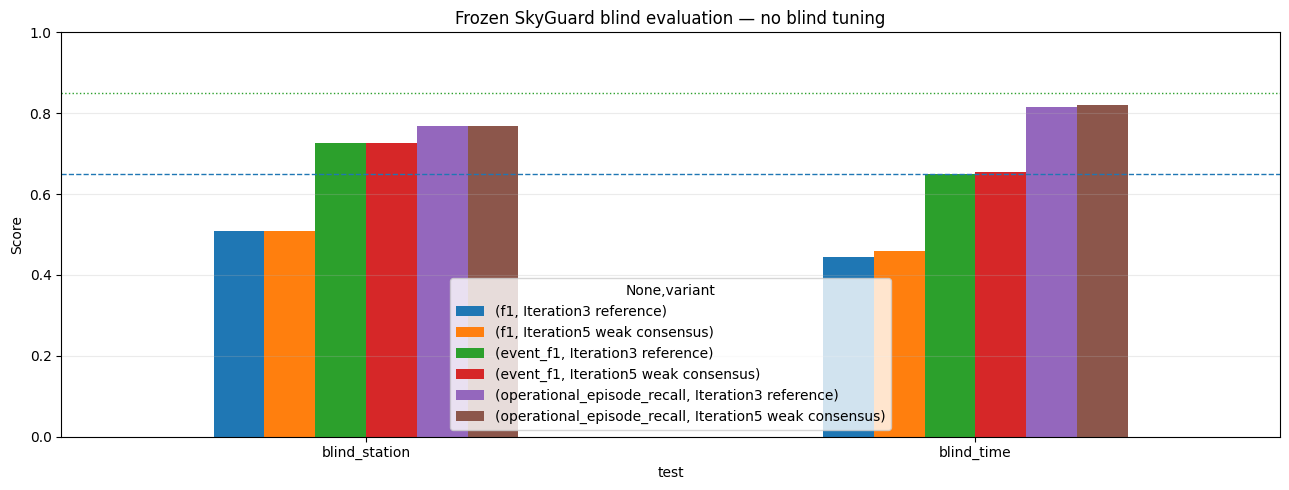

SEND BACK THESE FILES:
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_result_block.json
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_comparison.csv
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_fault_episode_recall.csv
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_point_fault_recall.csv
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_weather_metrics.csv
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_communication_replay.csv
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_readiness_checks.csv
/content/drive/MyDrive/SkyGuard_AI_GPU/experiments/blind_2025_final_comparison/blind_2025_open_receipt.json


In [39]:
import matplotlib.pyplot as plt

plot_table=comparison.pivot(index='test',columns='variant',values=['f1','event_f1','operational_episode_recall'])
axes=plot_table.plot(kind='bar',figsize=(13,5),ylim=(0,1),rot=0)
axes.axhline(.65,color='tab:blue',linestyle='--',linewidth=1,label='point-F1 target')
axes.axhline(.85,color='tab:green',linestyle=':',linewidth=1,label='episode-recall target')
axes.set_title('Frozen SkyGuard blind evaluation — no blind tuning')
axes.set_ylabel('Score')
axes.grid(axis='y',alpha=.25)
plt.tight_layout(); plt.show()

print('SEND BACK THESE FILES:')
for filename in [
    'blind_2025_result_block.json','blind_2025_comparison.csv',
    'blind_2025_fault_episode_recall.csv','blind_2025_point_fault_recall.csv',
    'blind_2025_weather_metrics.csv','blind_2025_communication_replay.csv',
    'blind_2025_readiness_checks.csv','blind_2025_open_receipt.json',
]:
    print(BLIND_OUTPUT_ROOT/filename)


## Decision rule after this notebook

- If the relative promotion gate fails on either test, keep Iteration 3 and diagnose the failed fault families. Do not tune on this 2025 benchmark.
- If the relative gate passes but strict SIH readiness fails, Iteration 5 is a valid research improvement but the complete detector still needs another development-only improvement cycle and a new future blind test.
- If both pass, package Iteration 5 for integration into the API/dashboard, retain advisory correction behavior, and run CPU latency/load testing as the final deployment gate.

The result is a measurement, not permission to retune against these labels.
